# Machine Learning Part 1
In this code, the data will be preprocessed and examined for later Machine Learning purposes.

In [2]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # Used later to export to PNG)
import random
import pandas as pd
import numpy as np
import pickle
import os
import chardet
import seaborn as sn
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.svm import SVR


from sklearn.metrics import auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_curve, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score, RocCurveDisplay, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA

# Some variables & constants:
subfolder = "dataframes-1-min"
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L


Importing all or only relevant features from the pickle files:

In [6]:
# Importing pickle files:
subfolder = "All Dataframes/dataframes-1-min"

pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")


Loaded Temperature_Monitoring_Outdoor_Temperarture from All Dataframes/dataframes-1-min
Loaded Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal from All Dataframes/dataframes-1-min
Loaded Battery_Current from All Dataframes/dataframes-1-min
Loaded Compressor_Stack_Coolant_Temperature_Out from All Dataframes/dataframes-1-min
Loaded Pressure_Transmitter_Maximum_Pressure from All Dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Flow from All Dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Feed_Temperature from All Dataframes/dataframes-1-min
Loaded Compressor_Compressor_Coolant_Temperature_In from All Dataframes/dataframes-1-min
Loaded Compressor_PLC_Warning_Register from All Dataframes/dataframes-1-min
Loaded Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal from All Dataframes/dataframes-1-min
Loaded Compressor_PLC_Yield_Output from All Dataframes/dataframes-1-min
Loaded Temperature_Monitoring_Hydrogen_Cabinet

In [8]:
alldataframes = []
column_names = []

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')  # Create a custom column name


# Concatenate all DataFrames and save the names
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names

correlation_matrix = combined_df.corr()
np.fill_diagonal(correlation_matrix.values, 0)

# Threshold from which we think a feature is worth saving
threshold = 0.9

# Looking for features that are strongly (above threshold)
strongly_correlated_columns = []
for column in correlation_matrix.columns:
    if (correlation_matrix[column].abs() > threshold).any():
        strongly_correlated_columns.append(column)


['Temperature_Monitoring_Outdoor_Temperarture', 'Battery_Current', 'Compressor_Stack_Coolant_Temperature_Out', 'Outdoor_Convector_Outdoor_Convector_Feed_Temperature', 'Compressor_Compressor_Coolant_Temperature_In', 'Compressor_PLC_Warning_Register', 'Compressor_PLC_Yield_Output', 'Temperature_Monitoring_Hydrogen_Cabinet_Temperature', 'Electrolyser_Outer_Hydrogen_Pressure', 'Compressor_Dryer_Pressure', 'Compressor_Compressor_Cooling_Pump_Control_Signal', 'Compressor_Energy_Meter_Power_Factor', 'Compressor_Anode_Heat_Tracing_Temperature', 'Ventilation_2_Emergency_Ventilation_2_Control_Signal', 'Ventilation_2_Ventilation_2_Air_Speed', 'Compressor_Energy_Meter_Apparent_Power', 'Compressor_Anode_Heat_Tracing_Control_Signal', 'Compressor_Energy_Meter_Voltage', 'Compressor_Power_On', 'Compressor_Set_State', 'Heat_Buffer_Heat_Buffer_Bottom_Temperature', 'Compressor_Energy_Meter_Current', 'Compressor_Compressor_Coolant_Temperature_Out', 'Battery_Inverter_AC_Out_Power', 'Indoor_Convector_Indoor_

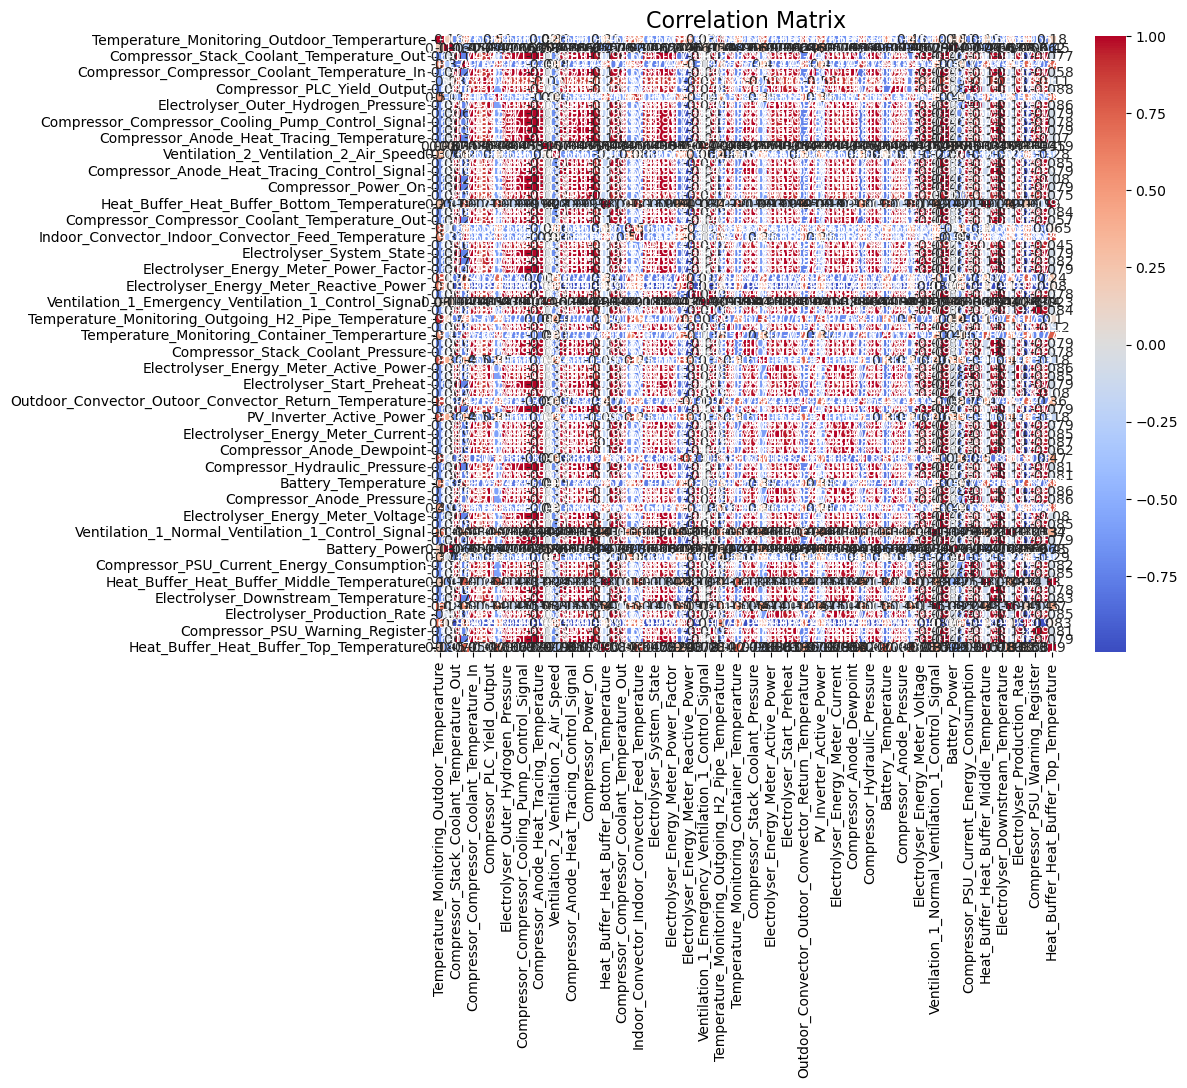

In [10]:
new = []
newnames = []
print(strongly_correlated_columns)
for var in strongly_correlated_columns:
    df = globals()[var]
    new.append(df[['value_float']])
    newnames.append(f'{var}') # Creating the column names

# Combinding the strongly correlated dataframes
new_combined_df = pd.concat(new, axis=1)
new_combined_df.columns = newnames

# Plot correlation matrix
correlation_matrix = new_combined_df.corr()
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sn.heatmap(correlation_matrix, annot=True, cmap="coolwarm",
            linewidths=0)

plt.title("Correlation Matrix", fontsize=16)
plt.savefig('Correlation Matrix.png')
plt.show()


### Classification Classifier
We introduce a classifier function that takes all information (model, train/test sets, and name) and gives us the performance metrics accuracy, f1 score, precision, recall, ROC & AUC, and the confusion matrix)

In [14]:

def Classifier(clf,x_train,y_train,x_test,y_test, name):
    figsubfolder = "figures/classification" # Here the figures for classification are saved
    if not os.path.exists(figsubfolder):
        os.makedirs(figsubfolder) # If the folder does not exist, it is created
        
    # Fit the model on training data
    clf.fit(x_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(x_test)

    # Print the scores
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score(y_test, y_pred, average='macro')
    F1score   = f1_score(y_test, y_pred, average='macro')
    print(f"For the {name} model")
    print("Accuracy: " + str(accuracy))
    print("Precision score: " + str(precision))
    print("Recall score: " + str(recall))
    print("F1 score: " + str(F1score))

    # Preparing for plotting
    num_classes = len(set(y_test))  # Number of unique classes in y_test
    class_labels = list(range(num_classes))  # Generate labels as 0,1,2,...,num_classes-1

    # Confusion matrix
    plt.figure(figsize=(5,5))
    confusion = confusion_matrix(y_test, y_pred)
    displayconfusion = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_labels) #display_labels=['0','1','2','3'])
    displayconfusion.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(os.path.join(figsubfolder, f"Confusion Matrix - {name}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    
    modelsubfolder = "models/classification" # Here the models for classification are saved
    if not os.path.exists(modelsubfolder): # If the folder does not exist, it is created
        os.makedirs(modelsubfolder)

    model_filename = os.path.join(modelsubfolder, f"{name}_model.pkl")
    with open(model_filename, 'wb') as model_file:
        pickle.dump(clf, model_file)
    print(f"Model saved as {model_filename}")


    if len(np.unique(y_test)) == 2: # if the classification has 2 outputs
      # ROC & AUC:
      lw = 2
      ax = plt.gca()
      y_score = clf.predict_proba(x_test)[:, 1]  # Use predict_proba for probabilities
      fpr_test, tpr_test, _ = roc_curve(y_test, y_score)
      auc_test = roc_auc_score(y_test, y_score)

      y_train_score = clf.predict_proba(x_train)[:, 1]
      fpr_train, tpr_train, _ = roc_curve(y_train, y_train_score)
      auc_train = roc_auc_score(y_train, y_train_score)
      plt.plot(fpr_test, tpr_test, lw=lw, label=f'Test ROC curve (area = {auc_test:.2f})')
      plt.plot(fpr_train, tpr_train , lw=lw, label=f'Train ROC curve (area = {auc_train:.2f})', linestyle='--')
      plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
      plt.xlim([0.0, 1.0])
      plt.ylim([0.0, 1.05])
      plt.xlabel('False Positive Rate')
      plt.ylabel('True Positive Rate')
      plt.title(f"ROC Curve for {name}")
      plt.legend(loc='lower right')
      plt.savefig(os.path.join(figsubfolder, f"ROC - {name}.png"), dpi=300, bbox_inches='tight')
      plt.show()



### Hydrogen production classification
We are starting by predicting wether hydrogen is being produced or not (System state)

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2248/751664050.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # Prepare target


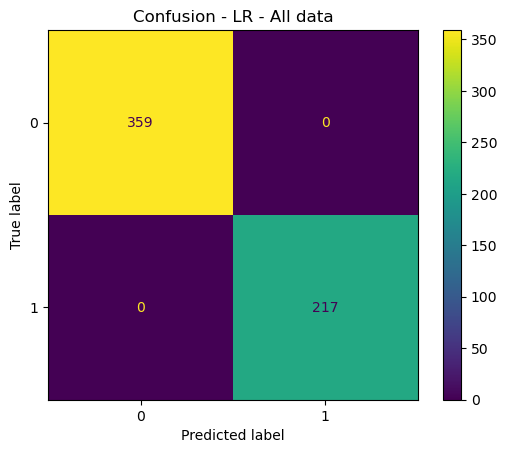

In [16]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 10 indicates hydrogen production

for var in DataframesToLoad: # Load all dataframes
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # Prepare target

# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

# one manual test with LR:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Performance:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion - LR - All data")
plt.savefig("Confusion - LR - All data")
plt.show()


Lets dumb this down, we'll only use the PV interter and weather data, this makes the prediction less accurate, but we want to see if we can predict hydrogen production at all with only these parameters.

   Temperature_Monitoring_Outdoor_Temperarture  \
0                                    17.400000   
1                                    17.366667   
2                                    17.116667   
3                                    17.025000   
4                                    16.966667   

   Electrolyser_Hydrogen_Flow_Rate  PV_Inverter_Active_Power  H2_Produced  
0                              0.0                       0.0            0  
1                              0.0                       0.0            0  
2                              0.0                       0.0            0  
3                              0.0                       0.0            0  
4                              0.0                       0.0            0  
Accuracy: 0.83
Precision: 0.77
Recall: 0.78
F1-Score: 0.78


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2248/2686317994.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


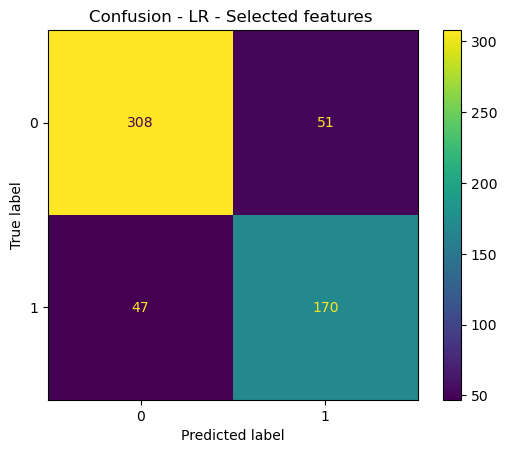

In [20]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 10 indicates hydrogen production (max is 500 NL/h)
# Importing pickle files:
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here

for var in DataframesToLoad:
    globals()[var] = pd.read_pickle(os.path.join(subfolder, f"{var}.pkl"))

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')

# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 


combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target

# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the columns we don't need anymore
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore') # We only use PV and temperature data now

print(combined_df.head()) # For debugging, may be removed later
combined_df.fillna(0, inplace=True) # Replace NaNs with 0 if needed

# Create the target column (1 for hydrogen production, 0 otherwise)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 1).astype(int) # 1 if hydrogen production is above 10 NL/h

# Separate features and target
X = combined_df.drop(columns=['H2_Produced', 'Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

# One more manual evaluation with fewer data (we threw away almost all columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion - LR - Selected features ")
plt.savefig("Confusion - LR - Selected features")
plt.show()



We can clearly see that some features are more important than others and so we can look up those features by PCA.

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00
Explained variance ratio: [0.65627564 0.08019985 0.05238738 0.03002972 0.02944837 0.02590218
 0.02103903 0.01839631 0.01316138 0.00979378]


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2248/2645076555.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target


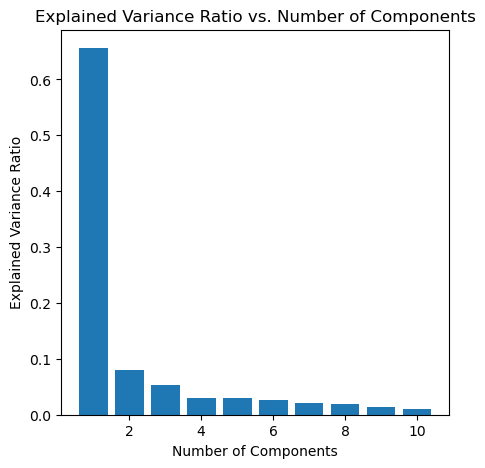

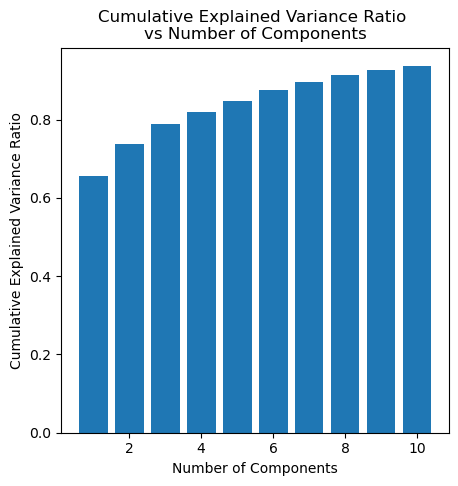

In [22]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 0 indicates hydrogen production
for var in DataframesToLoad: # Load all dataframes again
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int) # prepare target

# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# Performance:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Now we'll try to see if PCA might be helpful
# Choose the number of principal components you want to keep
n_components = 10  # You can adjust this based on explained variance ratio

# Create a PCA object
pca = PCA(n_components=n_components)

# Fit and transform the training data
x_train_pca = pca.fit_transform(X_train_scaled)
x_test_pca = pca.transform(X_test_scaled)

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# You can now use x_train_2c_pca and x_test_2c_pca for training and testing your model
# with the reduced dimensionality data.


plt.figure(figsize=(5,5))

plt.bar(range(1, n_components+1), pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio vs. Number of Components')
plt.savefig("explained variance ratio")

plt.show()

plt.figure(figsize=(5,5))
cumul_expl_var_ratio=np.cumsum(pca.explained_variance_ratio_[0:20])
plt.bar(range(1, n_components+1), cumul_expl_var_ratio)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Cumulative Explained Variance Ratio \nvs Number of Components")
plt.savefig("explained variance cumulative")
plt.show()

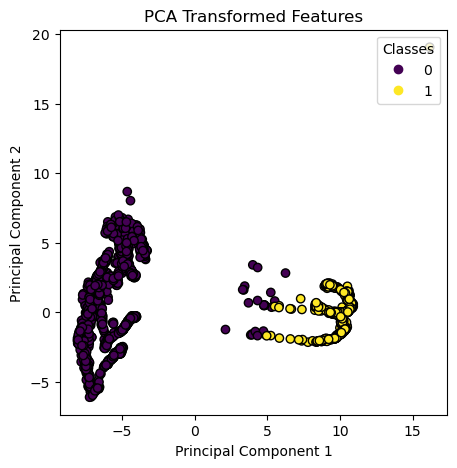

In [24]:
# We'll try if we can see if PCA is helpful.

pca = PCA()
x_pca = pca.fit_transform(X_train_scaled)

# Plot the first two principal components of each point

plt.figure(figsize=(5,5))
# plt.scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Features')
legend = plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.savefig("PCA - 2 class")
plt.show()

### Multiple model testing
Here we test different types of classification models to test the  best ones for this purpose. As seen before, when using all of the available data, we get an accuracy of 100%, so to better distinguish results, the slimmed down dataset is used here.

   Temperature_Monitoring_Outdoor_Temperarture  \
0                                    17.400000   
1                                    17.366667   
2                                    17.116667   
3                                    17.025000   
4                                    16.966667   

   Electrolyser_Hydrogen_Flow_Rate  PV_Inverter_Active_Power  
0                              0.0                       0.0  
1                              0.0                       0.0  
2                              0.0                       0.0  
3                              0.0                       0.0  
4                              0.0                       0.0  
For the Logistic Regression model
Accuracy: 0.8472222222222222
Precision score: 0.8417292278678418
Recall score: 0.862855089020962
F1 score: 0.8437388248350699


<Figure size 500x500 with 0 Axes>

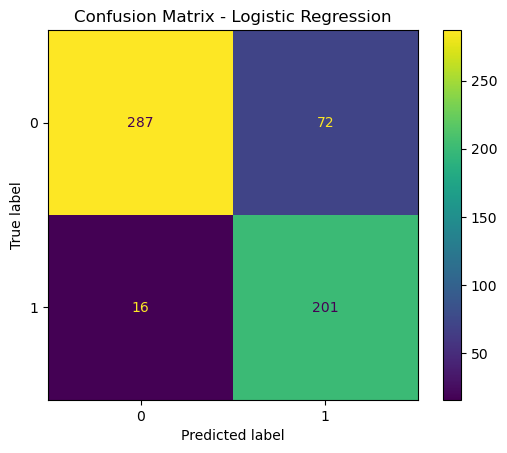

Model saved as models/classification/Logistic Regression_model.pkl


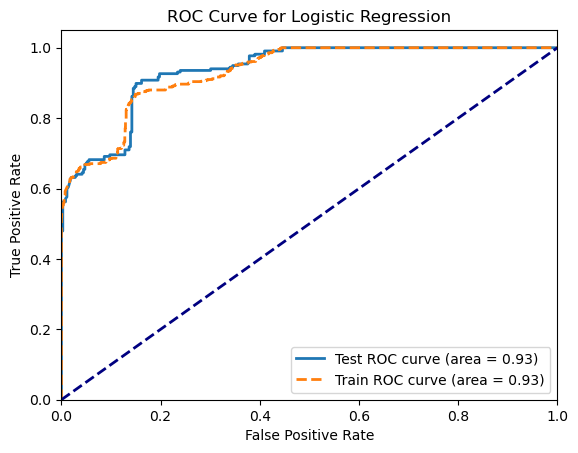

Training k-NN with n_neighbors=1
For the KNN - 1 model
Accuracy: 0.9670138888888888
Precision score: 0.9630859673232555
Recall score: 0.96715787581993
F1 score: 0.9650359257141214


<Figure size 500x500 with 0 Axes>

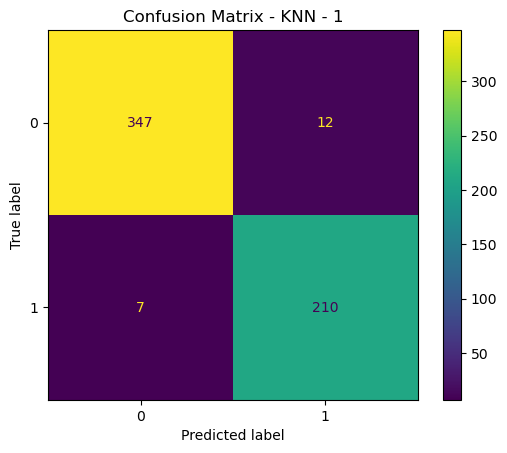

Model saved as models/classification/KNN - 1_model.pkl


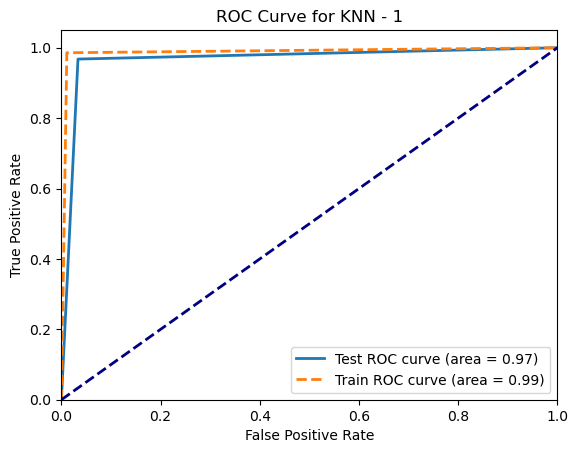

Training k-NN with n_neighbors=2
For the KNN - 2 model
Accuracy: 0.9565972222222222
Precision score: 0.9608857944617991
Recall score: 0.9469532623904086
F1 score: 0.9531138584364123


<Figure size 500x500 with 0 Axes>

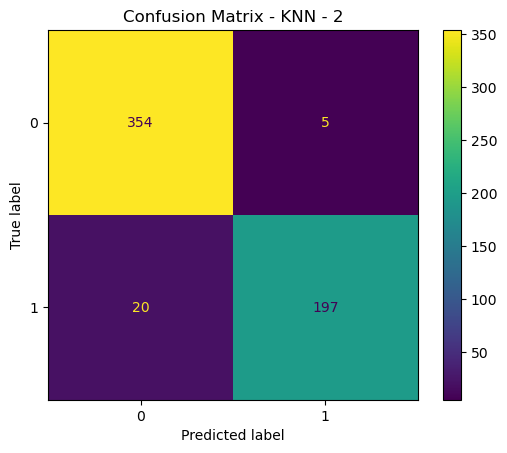

Model saved as models/classification/KNN - 2_model.pkl


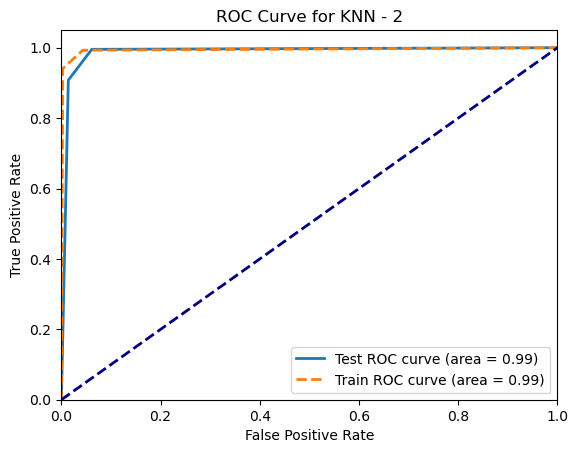

Training k-NN with n_neighbors=3
For the KNN - 3 model
Accuracy: 0.9670138888888888
Precision score: 0.9618836915297093
Recall score: 0.9689806554304712
F1 score: 0.9651561510027477


<Figure size 500x500 with 0 Axes>

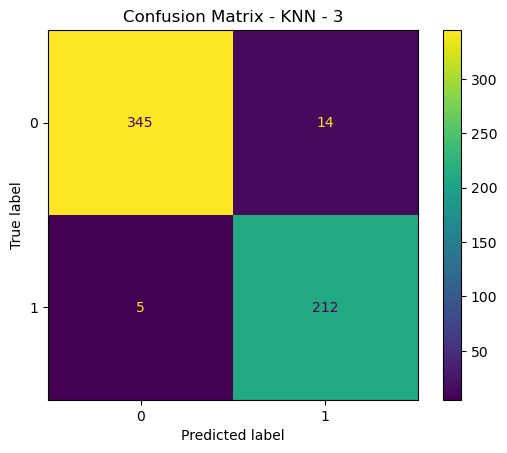

Model saved as models/classification/KNN - 3_model.pkl


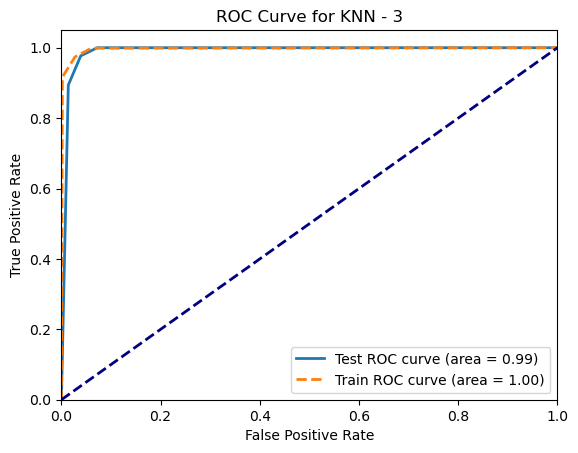

Training k-NN with n_neighbors=4
For the KNN - 4 model
Accuracy: 0.9583333333333334
Precision score: 0.9556371384927409
Recall score: 0.9556371384927409
F1 score: 0.9556371384927409


<Figure size 500x500 with 0 Axes>

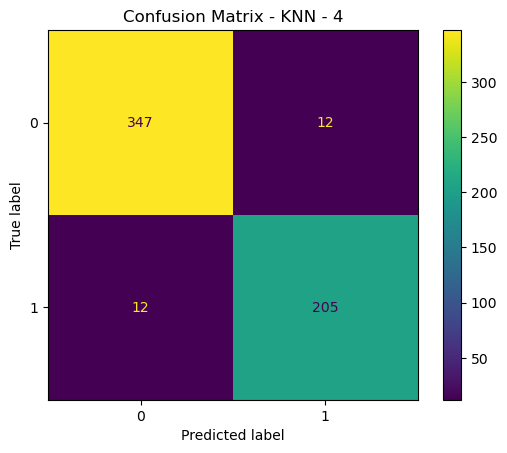

Model saved as models/classification/KNN - 4_model.pkl


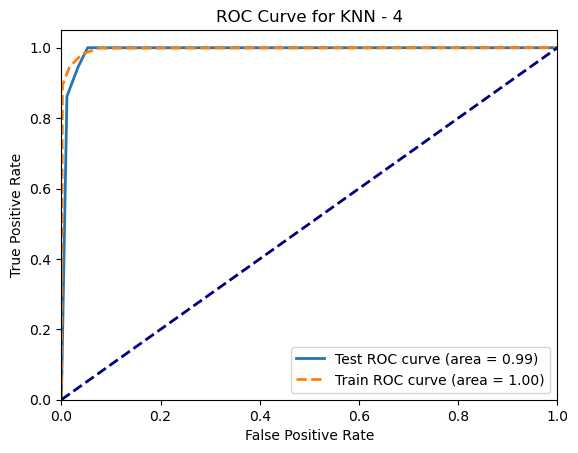

Training k-NN with n_neighbors=7
For the KNN - 7 model
Accuracy: 0.9600694444444444
Precision score: 0.9523022226642136
Recall score: 0.9670551840108854
F1 score: 0.9582259920853895


<Figure size 500x500 with 0 Axes>

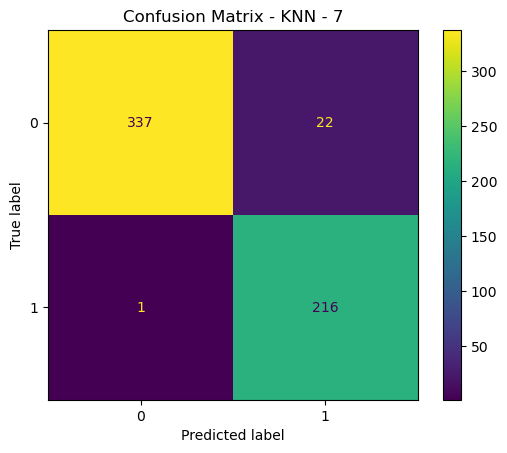

Model saved as models/classification/KNN - 7_model.pkl


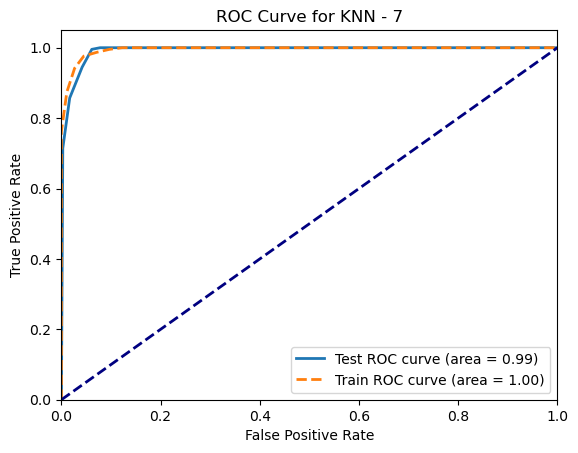

Training SVC with kernel=rbf
For the svm rbf model
Accuracy: 0.90625
Precision score: 0.9152830579940554
Recall score: 0.8856013247243366
F1 score: 0.8968358208955224


<Figure size 500x500 with 0 Axes>

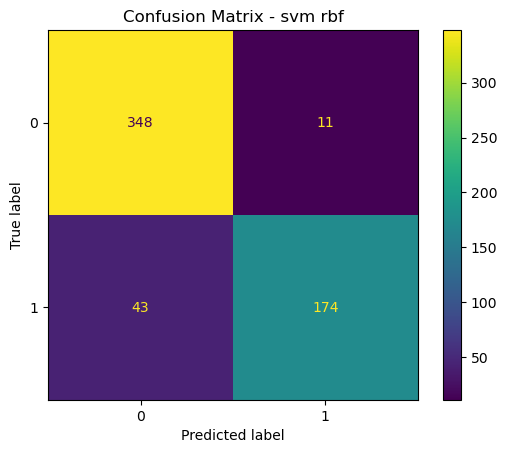

Model saved as models/classification/svm rbf_model.pkl


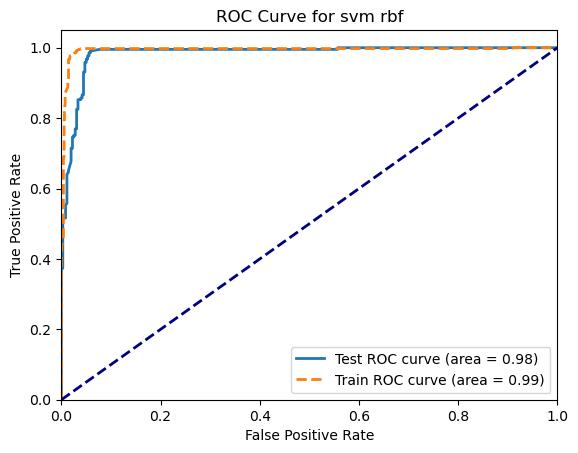

For the Decision Tree model
Accuracy: 0.9756944444444444
Precision score: 0.9733317984728138
Recall score: 0.9750330539260362
F1 score: 0.9741684178155912


<Figure size 500x500 with 0 Axes>

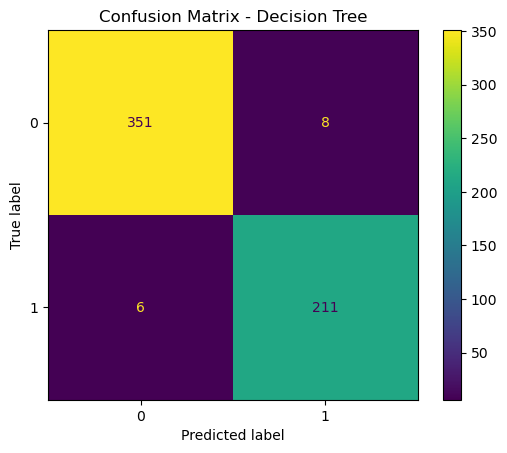

Model saved as models/classification/Decision Tree_model.pkl


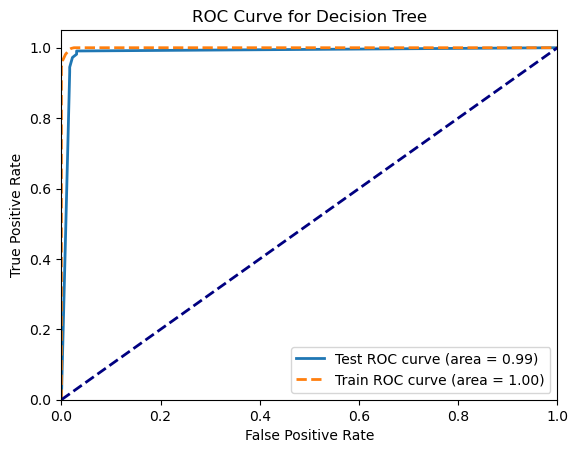

For the Random Forest model
Accuracy: 0.9791666666666666
Precision score: 0.9749287749287749
Recall score: 0.9814641284674531
F1 score: 0.9779746351411638


<Figure size 500x500 with 0 Axes>

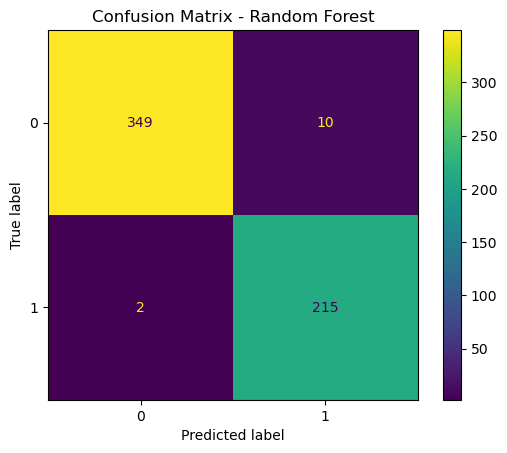

Model saved as models/classification/Random Forest_model.pkl


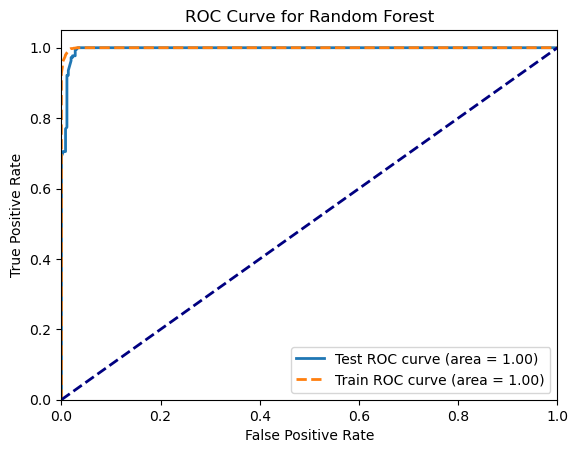

For the XGBoost model
Accuracy: 0.9826388888888888
Precision score: 0.9779735682819384
Recall score: 0.9860724233983287
F1 score: 0.9816765918460834


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [14:08:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 500x500 with 0 Axes>

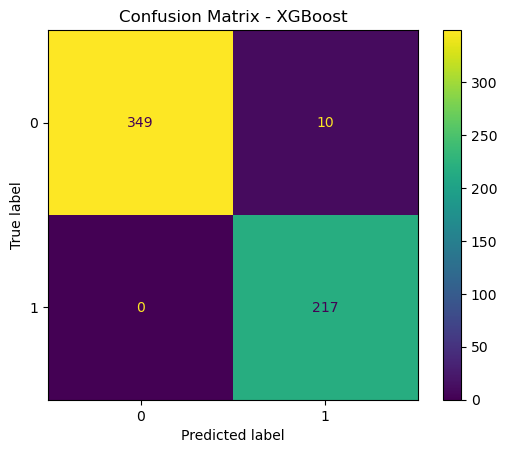

Model saved as models/classification/XGBoost_model.pkl


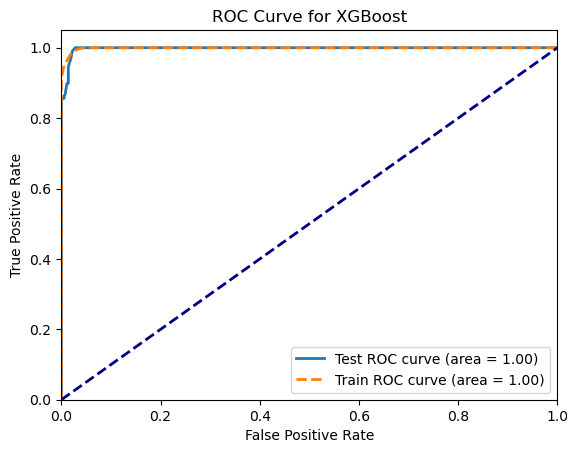

For the Naive Bayes model
Accuracy: 0.7777777777777778
Precision score: 0.7918992884510125
Recall score: 0.8080561724195474
F1 score: 0.7764734416686878


<Figure size 500x500 with 0 Axes>

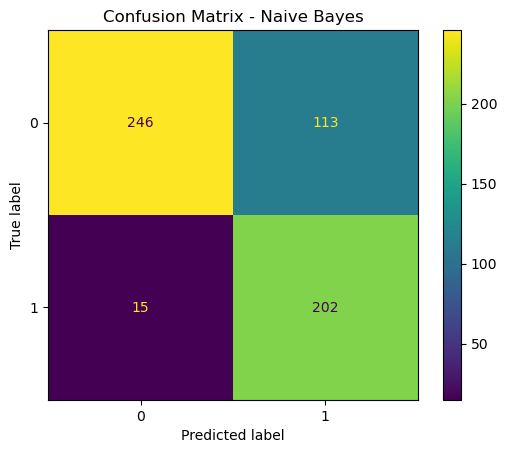

Model saved as models/classification/Naive Bayes_model.pkl


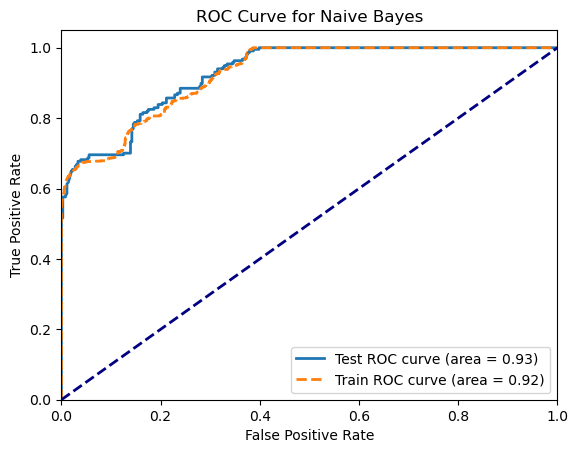

For the Neural Network - 100 model
Accuracy: 0.9618055555555556
Precision score: 0.9548542899685932
Recall score: 0.9666251620605111
F1 score: 0.9598860398860398


<Figure size 500x500 with 0 Axes>

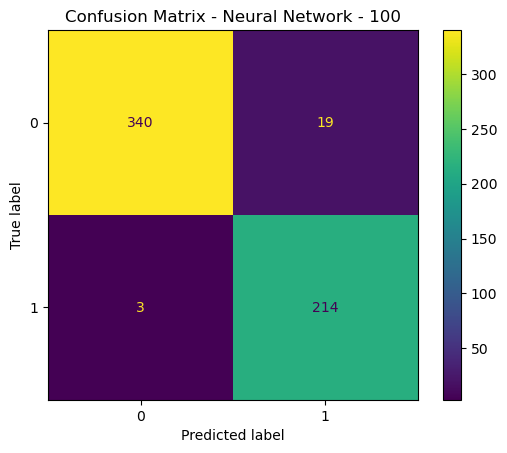

Model saved as models/classification/Neural Network - 100_model.pkl


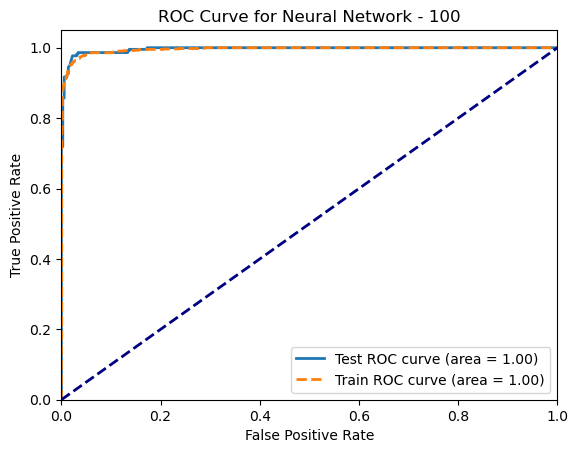

For the Neural Network - (100, 100) model
Accuracy: 0.9583333333333334
Precision score: 0.950207468879668
Recall score: 0.9665738161559889
F1 score: 0.9565080603551338


<Figure size 500x500 with 0 Axes>

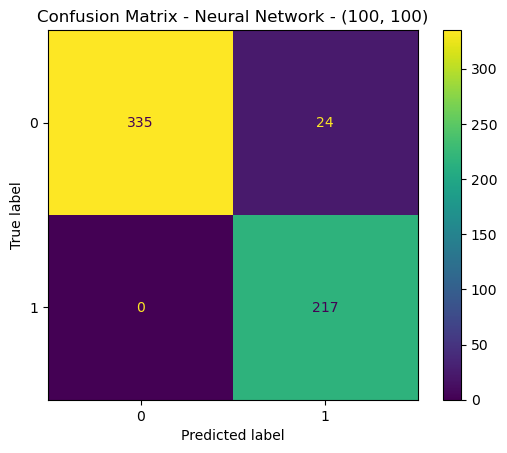

Model saved as models/classification/Neural Network - (100, 100)_model.pkl


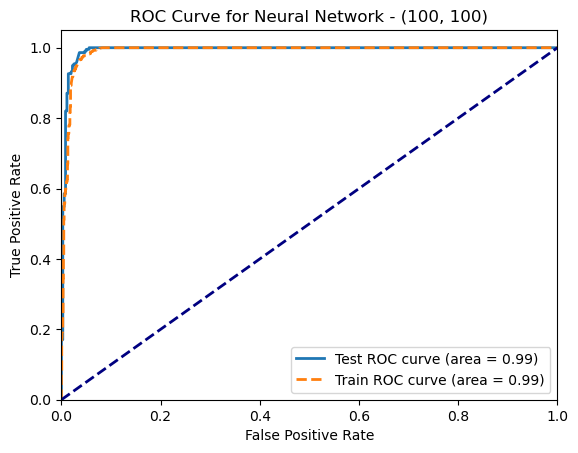

For the Neural Network - (100, 100, 100) model
Accuracy: 0.7725694444444444
Precision score: 0.866326530612245
Recall score: 0.6981566820276498
F1 score: 0.7066787950879894


<Figure size 500x500 with 0 Axes>

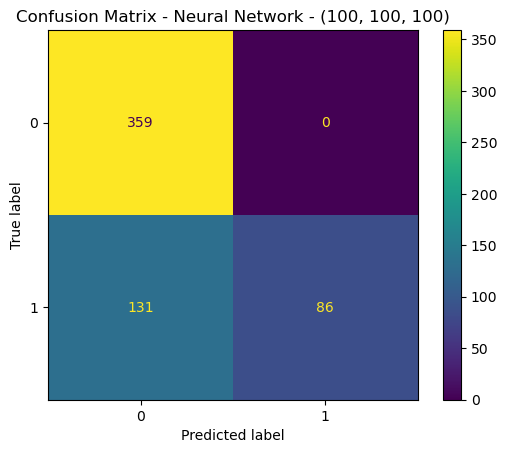

Model saved as models/classification/Neural Network - (100, 100, 100)_model.pkl


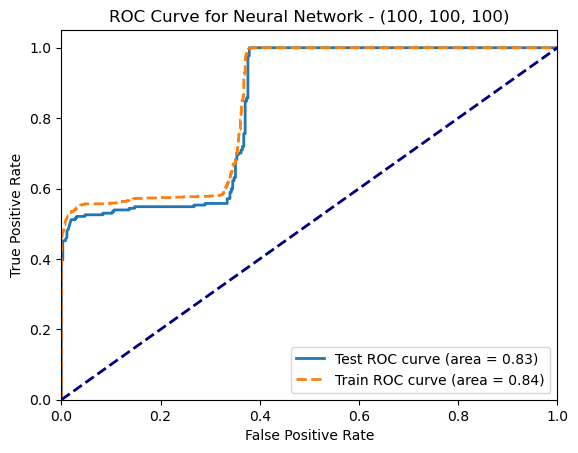

In [26]:
# Define the target column (binary classification)
# Assuming Electrolyser_Hydrogen_Flow_Rate > 1 indicates hydrogen production
# Importing pickle files:
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]
 
# Load all pickle files available, or just the ones we need
DataframesToLoad =  pickle_files # ["Battery_Current", "PV_Inverter_Active_Power","Battery_State_Of_Charge", "Electrolyser_Hydrogen_Flow_Rate"] # Please put the names of the dataframes (features) to load here

for var in DataframesToLoad:
    globals()[var] = pd.read_pickle(os.path.join(subfolder, f"{var}.pkl"))

for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')

# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names 

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)


# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the specified columns
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')

print(combined_df.head())

# Clean up the dataframe by removing NaN values (replace NaNs with 0 if needed)
combined_df.fillna(0, inplace=True)

# Create the binary target column (1 for hydrogen production, 0 otherwise)
combined_df = pd.concat([combined_df, 
                         (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int).rename('H2_Produced')], 
                         axis=1)


# Separate features and target
X = combined_df.drop(columns=['H2_Produced', 'Electrolyser_Hydrogen_Flow_Rate'])  # All features except target(s)
y = combined_df['H2_Produced']  # Target (1 or 0)

X_scaled = scaler.fit_transform(X)

# Split data into training and test sets
x_train_2c, x_test_2c, y_train_2c, y_test_2c = train_test_split(X, y, test_size=0.2, random_state=42)


#Logistic regression - does not work well enough
LRmodel =  LogisticRegression(class_weight='balanced')
Classifier(LRmodel,x_train_2c,y_train_2c,x_test_2c,y_test_2c, 'Logistic Regression')

# K-NN:
for n in [1,2,3,4,7]:
    print(f"Training k-NN with n_neighbors={n}")
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    Classifier(knn_clf,x_train_2c,y_train_2c,x_test_2c,y_test_2c, f'KNN - {n}')

### SVM: - kernels=['linear','poly','rbf'], [gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3]
kernels = ['rbf'] # poly gave long runtimes
for kernel in kernels:
    print(f"Training SVC with kernel={kernel}")
    if kernel == 'poly':
        svm_clf = SVC(kernel=kernel, degree=3, gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3, probability=True)
    else:
        svm_clf = SVC(kernel=kernel, gamma='auto', random_state=42, C=1.0, coef0=0.0, tol=1e-3, probability=True)
    Classifier(svm_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, f'svm {kernel}')

# Decision tree:
dt_clf = DecisionTreeClassifier(random_state=42)
Classifier(dt_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Decision Tree')

# Random forest:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
Classifier(rf_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Random Forest')

# Gradient boosting:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
Classifier(xgb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'XGBoost')

# Naive bays:
nb_clf = GaussianNB()
Classifier(nb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'Naive Bayes')

for hidden_layers in [(100), (100,100), (100,100,100)]:
    mlp_clf = MLPClassifier(hidden_layers, max_iter=500, random_state=42)
    Classifier(mlp_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, f'Neural Network - {hidden_layers}')

From the model evaluation above, we can conclude that the KNN 3 works best for the more simple models and Gradient Boost model for the more advanced models, so we can tune these models further.

Training k-NN with n_neighbors=3
For the KNN - 3 model
Accuracy: 0.9079861111111112
Precision score: 0.8972639036090813
Recall score: 0.8916115639992852
F1 score: 0.8943400928262156


<Figure size 500x500 with 0 Axes>

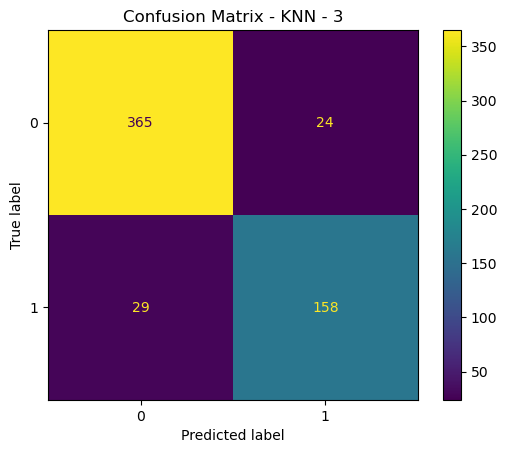

Model saved as models/classification/KNN - 3_model.pkl


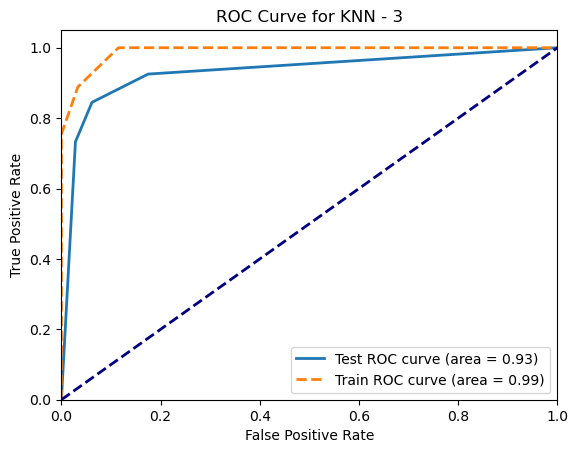

For the XGBoost model
Accuracy: 0.9548611111111112
Precision score: 0.9454943925107212
Recall score: 0.9526964793863327
F1 score: 0.9489500954458685


<Figure size 500x500 with 0 Axes>

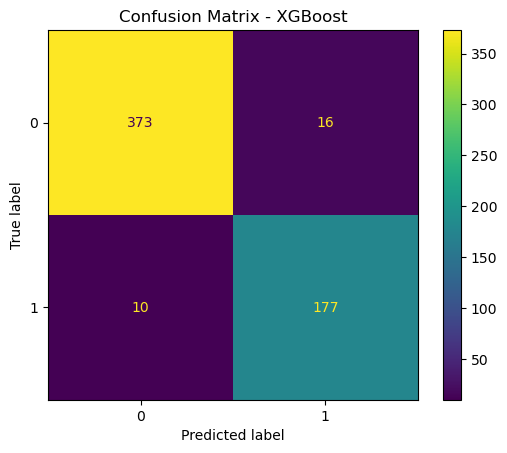

Model saved as models/classification/XGBoost_model.pkl


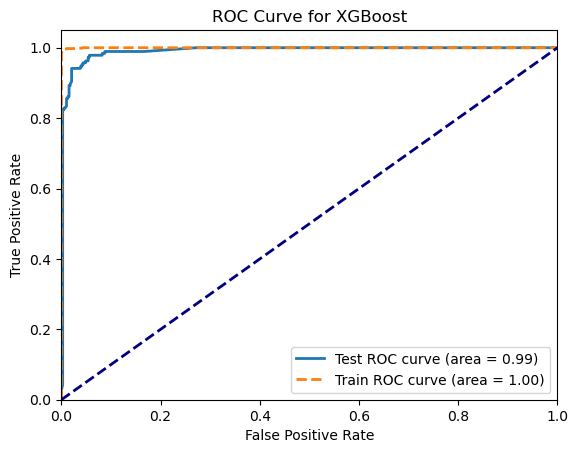

In [126]:
from sklearn.metrics import classification_report
for n in [3]:
    print(f"Training k-NN with n_neighbors={n}")
    knn_clf = KNeighborsClassifier(n_neighbors=n)
    Classifier(knn_clf,x_train_2c,y_train_2c,x_test_2c,y_test_2c, f'KNN - {n}')

# Gradient boosting:
xgb_clf = XGBClassifier(eval_metric='logloss', random_state=42)
Classifier(xgb_clf, x_train_2c, y_train_2c, x_test_2c, y_test_2c, 'XGBoost')


In [128]:
# We also try how to do grid search for later use:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(x_train_2c, y_train_2c)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
Best score: 0.9075516363293407


# Machine learning part 2
This part of the machine learning will cover an estimation on hydrogen production based on temperature and PV power.

In [28]:
alldataframes = []
column_names = []

# We set up the features and target:
for var in DataframesToLoad:
    df = globals()[var]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var}')
    
# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names
combined_df['time'] = globals()[DataframesToLoad[0]]['time']

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df['H2_Produced'] = combined_df['Electrolyser_Hydrogen_Flow_Rate'] # prepare target

# List of columns to drop (you can modify this list based on your requirements)
columns_to_drop = [
    "Battery_Current", "Battery_Power", "Battery_State_Of_Charge", "Battery_Temperature", 
    "Battery_Voltage", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power",
    "Battery_Inverter_Grid_Setpoint", "Compressor_Anode_Dewpoint", "Compressor_Anode_Heat_Tracing_Control_Signal",
    "Compressor_Anode_Heat_Tracing_Temperature", "Compressor_Anode_Pressure", "Compressor_Anode_Relative_Humidity",
    "Compressor_Anode_Temperature", "Compressor_Cathode_Pressure", "Compressor_Compressor_Coolant_Flow",
    "Compressor_Compressor_Coolant_Temperature_In", "Compressor_Compressor_Coolant_Temperature_Out",
    "Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal", "Compressor_Compressor_Cooling_Pump_Control_Signal",
    "Compressor_Current_State", "Compressor_Dryer_Pressure", "Compressor_Hydraulic_Pressure",
    "Compressor_Internal_Cooling_Heater_Control_Signal", "Compressor_PLC_Alarm_Register", "Compressor_PLC_Warning_Register",
    "Compressor_PLC_Yield_Output", "Compressor_PSU_Alarm_Register", "Compressor_PSU_Control_Register",
    "Compressor_PSU_Current_Energy_Consumption", "Compressor_PSU_Warning_Register", "Compressor_Power_On",
    "Compressor_Set_State", "Compressor_Stack_Coolant_Flow", "Compressor_Stack_Coolant_Pressure",
    "Compressor_Stack_Coolant_Temperature_In", "Compressor_Stack_Coolant_Temperature_Out",
    "Compressor_Stack_Cooling_Pump_Control_Signal", "Compressor_Energy_Meter_Active_Power",
    "Compressor_Energy_Meter_Apparent_Power", "Compressor_Energy_Meter_Current", "Compressor_Energy_Meter_Phase_Angle",
    "Compressor_Energy_Meter_Power_Factor", "Compressor_Energy_Meter_Reactive_Power", "Compressor_Energy_Meter_Voltage",
    "Drain_Drain_High_Level_Switch", "Electrolyser_Downstream_Temperature", "Electrolyser_Electrolyser_State",
    "Electrolyser_Electrolyte_Temperature", "Electrolyser_Inner_Hydrogen_Pressure", "Electrolyser_Outer_Hydrogen_Pressure",
    "Electrolyser_Power_On", "Electrolyser_Production_Rate", "Electrolyser_Stack_Current", "Electrolyser_Stack_Voltage",
    "Electrolyser_Start_Electrolyser", "Electrolyser_Start_Preheat", "Electrolyser_System_State", "Electrolyser_Water_Filling",
    "Electrolyser_Water_Inlet_Pressure", "Electrolyser_Energy_Meter_Active_Power", "Electrolyser_Energy_Meter_Apparent_Power",
    "Electrolyser_Energy_Meter_Current", "Electrolyser_Energy_Meter_Phase_Angle", "Electrolyser_Energy_Meter_Power_Factor",
    "Electrolyser_Energy_Meter_Reactive_Power", "Electrolyser_Energy_Meter_Voltage", "Heat_Buffer_Heat_Buffer_Bottom_Temperature",
    "Heat_Buffer_Heat_Buffer_Middle_Temperature", "Heat_Buffer_Heat_Buffer_Top_Temperature", "Indoor_Convector_Indoor_Convector_Feed_Temperature",
    "Indoor_Convector_Indoor_Convector_Flow", "Indoor_Convector_Indoor_Convector_Pump_Control_Signal",
    "Indoor_Convector_Indoor_Convector_Return_Temperature", "Mode_Selector_Mode_Selector_Battery", "Mode_Selector_Mode_Selector_Hydrogen",
    "Outdoor_Convector_Outdoor_Convector_Fan_Control_Signal", "Outdoor_Convector_Outdoor_Convector_Feed_Temperature",
    "Outdoor_Convector_Outdoor_Convector_Flow", "Outdoor_Convector_Outdoor_Convector_Pump_Control_Signal",
    "Outdoor_Convector_Outoor_Convector_Return_Temperature", "Pressure_Transmitter_Buffer_Status",
    "Pressure_Transmitter_Maximum_Pressure", "Pressure_Transmitter_Pressure", "Pressure_Transmitter_State_Of_Charge",
    "Temperature_Control_Compressor_Buffer_Cooling_Control_Signal", "Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal",
    "Temperature_Control_Indoor_Convector_Control_Signal", "Temperature_Control_Outgoing_H2_Pipe_Heat_Tracing_Controller_Control_Signal",
    "Temperature_Monitoring_Battery_Cabinet_Temperature", "Temperature_Monitoring_Container_Temperarture", 
    "Temperature_Monitoring_Hydrogen_Cabinet_Temperature",
    "Temperature_Monitoring_Outgoing_H2_Pipe_Temperature", "Ventilation_1_Emergency_Ventilation_1_Control_Signal",
    "Ventilation_1_Normal_Ventilation_1_Control_Signal", "Ventilation_1_Ventilation_1_Air_Speed", "Ventilation_2_Emergency_Ventilation_2_Control_Signal",
    "Ventilation_2_Normal_Ventilation_2_Control_Signal", "Ventilation_2_Ventilation_2_Air_Speed", "Water_Tank_Water_Feed_Tank_Low_Level_Switch"
]

# Drop the columns we don't need anymore
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')


# Separate features and target
X = combined_df.drop(columns=['H2_Produced','Electrolyser_Hydrogen_Flow_Rate','time'])  # All features except target(s)
y = combined_df['H2_Produced']  # float value target, not binary

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

time_train = combined_df.loc[X_train.index, 'time']  # Get corresponding time for train data (for plotting later)
time_test = combined_df.loc[X_test.index, 'time']    # Get corresponding time for test data (for plotting later)


/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2248/1821584037.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['time'] = globals()[DataframesToLoad[0]]['time']
/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_2248/1821584037.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df['H2_Produced'] = combined_df['Electrolyser_Hydrogen_Flow_Rate'] # prepare target


### Regression Classifier

In [30]:

def Regression_Classifier(clf,x_train,y_train,x_test,y_test, name):
    print(f"Evaluating model: {name}")
    #fit the model
    clf.fit(x_train, y_train)
    figsubfolder = "figures/regression" # Where we save the figures for regression
    if not os.path.exists(figsubfolder):
        os.makedirs(figsubfolder)

    modelsubfolder = "models/regression" # Where we save the models for regression
    if not os.path.exists(modelsubfolder):
        os.makedirs(modelsubfolder)

    model_filename = os.path.join(modelsubfolder, f"{name}_model.pkl")
    with open(model_filename, 'wb') as model_file:
        pickle.dump(clf, model_file)  # Save the model
    print(f"Model saved as {model_filename}")


    # Making predictions on the test set:
    y_pred = clf.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # We need to sort the predictions to make a plot:
    predicted_df = pd.DataFrame({'time': time_test, 'predicted': y_pred})
    predicted_df = predicted_df.sort_values(by='time')
    time_test_sorted = predicted_df['time']
    y_pred_sorted = predicted_df['predicted']

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    evs = explained_variance_score(y_test, y_pred)
    print(f"Explained Variance Score: {evs:.2f}")

    # Scatter plot:
    plt.figure()
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Hydrogen Production")
    plt.ylabel("Predicted Hydrogen Production")
    plt.title(f"Actual vs Predicted - model: {name}")
    plt.savefig(os.path.join(figsubfolder, f"predictions - {name}.png"), dpi=300, bbox_inches='tight')

    plt.show()

    # Rediduals plot:
    plt.figure()
    residuals = y_test - y_pred
    plt.scatter(y_test, residuals, alpha=0.5)
    plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), colors='red', linewidth=2)
    plt.xlabel("Actual Hydrogen Production")
    plt.ylabel("Residuals")
    plt.title(f"Residuals Plot - model: {name}")
    plt.savefig(os.path.join(figsubfolder, f"Residuals Plot - {name}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # Timeseries plot:
    plt.figure(figsize=(10, 6))
    test_index = X_test.index
    
    # Plot actual vs time
    plt.plot(combined_df['time'], combined_df['H2_Produced'], label='Actual Hydrogen Production', color='blue')
    
    # Plot predicted vs time
    plt.plot(time_test_sorted, y_pred_sorted, label='Predicted Hydrogen Production', color='red', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Hydrogen Production')
    plt.title(f'Actual vs Predicted Hydrogen Production Over Time {name}')
    plt.xlim(min(combined_df['time']), max(combined_df['time']))
    plt.legend()
    plt.xticks(rotation=45)  # Rotate time labels if needed
    plt.tight_layout()
    plt.savefig(os.path.join(figsubfolder, f"timeseries Actual vs predicted - {name}.png"), dpi=300, bbox_inches='tight')
    plt.show()
    print() # blank line for easier reading

    return time_test_sorted, y_pred_sorted

### Multiple model testing:
here multiple different regression models are tested for their performance 

Evaluating model: linear regression
Model saved as models/regression/linear regression_model.pkl
Mean Absolute Error (MAE): 142.01
Mean Squared Error (MSE): 27580.08
R² Score: 0.49
Explained Variance Score: 0.49


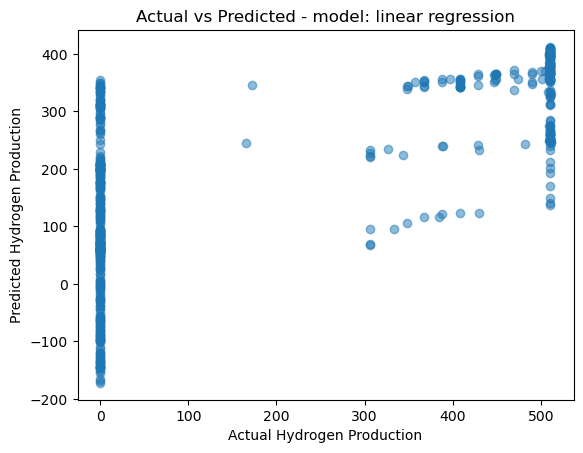

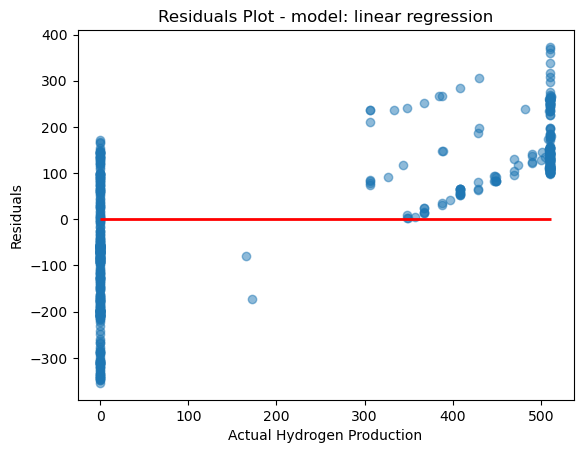

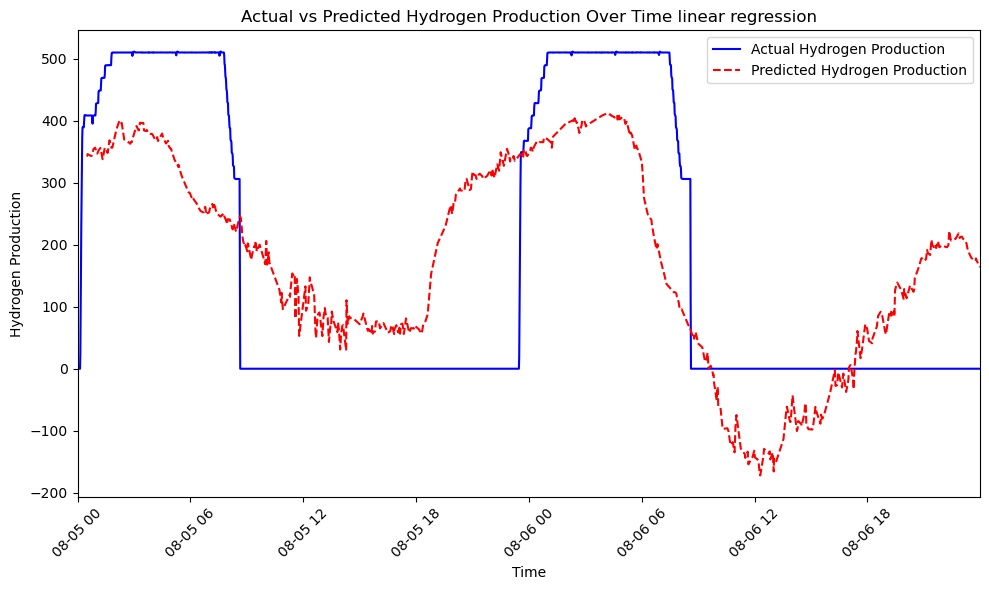


Evaluating model: Lasso Regression (alpha=0.1)
Model saved as models/regression/Lasso Regression (alpha=0.1)_model.pkl
Mean Absolute Error (MAE): 142.04
Mean Squared Error (MSE): 27583.59
R² Score: 0.49
Explained Variance Score: 0.49


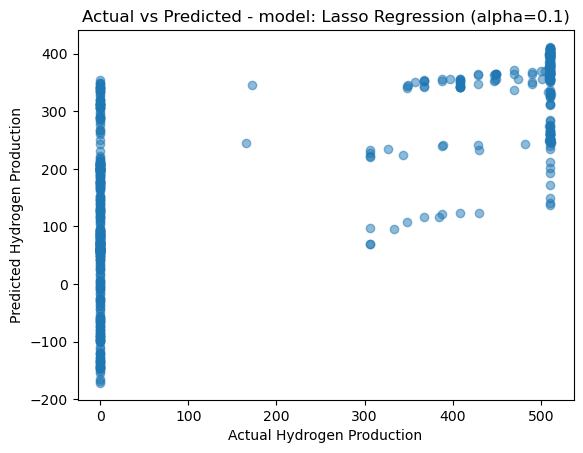

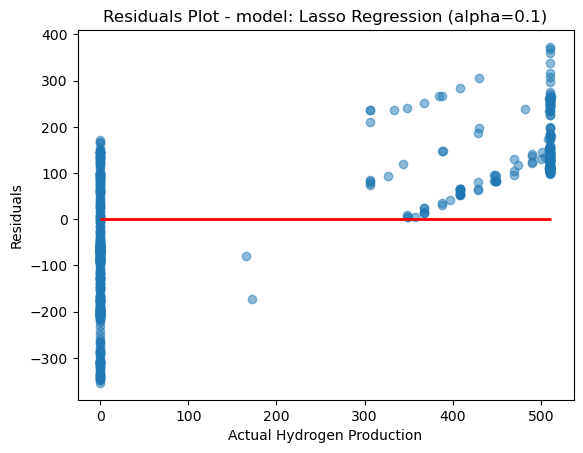

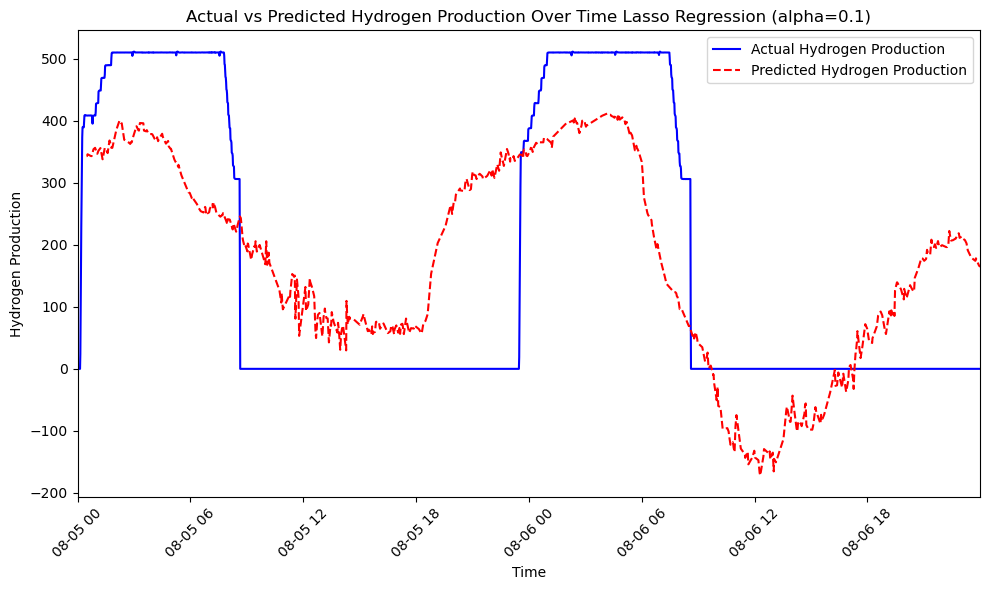


Evaluating model: Lasso Regression (alpha=1)
Model saved as models/regression/Lasso Regression (alpha=1)_model.pkl
Mean Absolute Error (MAE): 142.27
Mean Squared Error (MSE): 27624.74
R² Score: 0.49
Explained Variance Score: 0.49


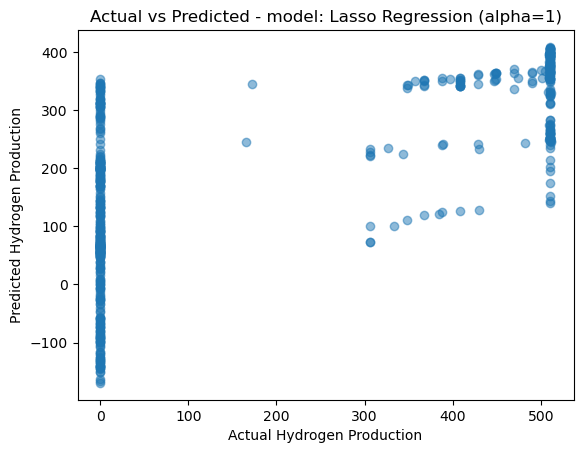

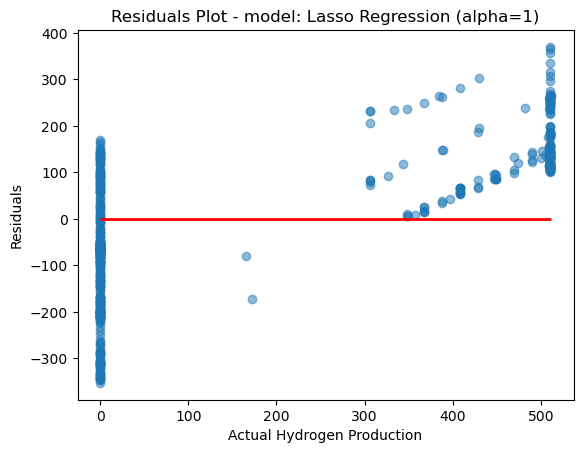

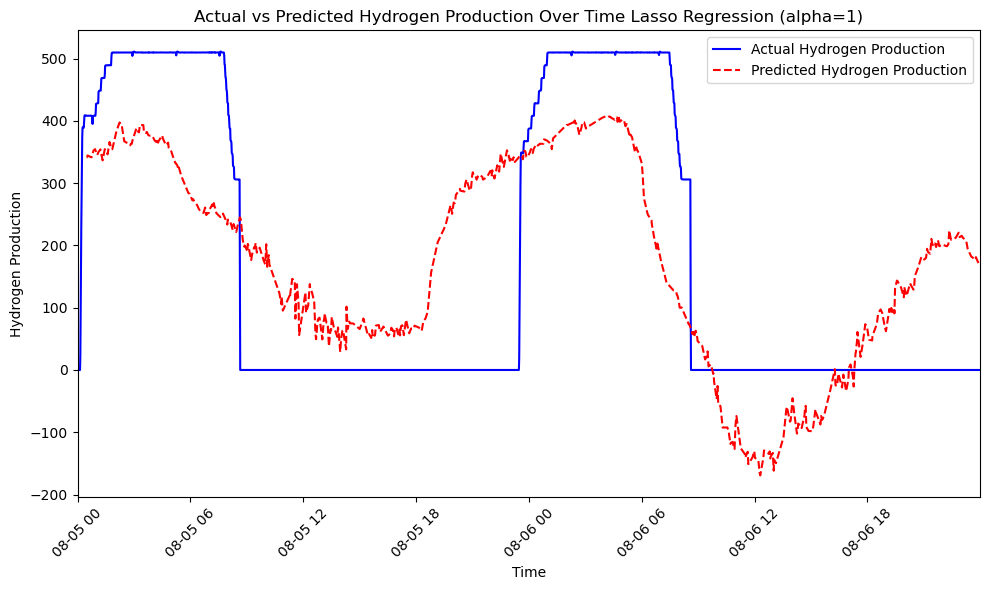


Evaluating model: Ridge Regression (alpha=0.1)
Model saved as models/regression/Ridge Regression (alpha=0.1)_model.pkl
Mean Absolute Error (MAE): 142.01
Mean Squared Error (MSE): 27580.25
R² Score: 0.49
Explained Variance Score: 0.49


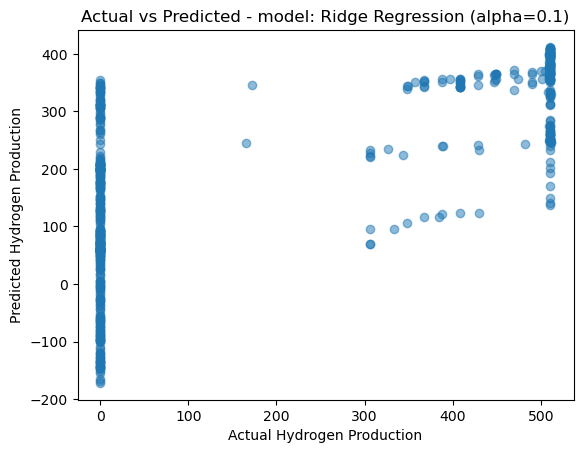

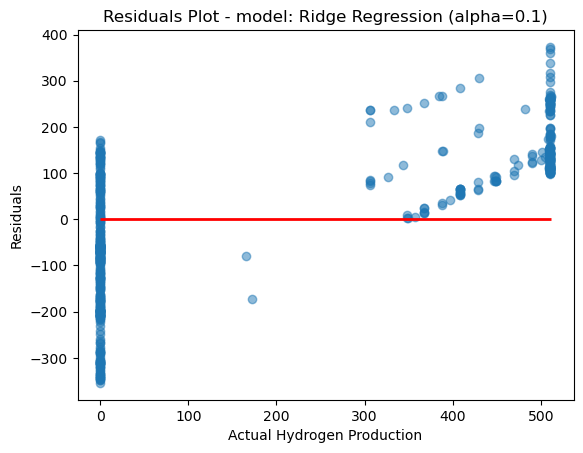

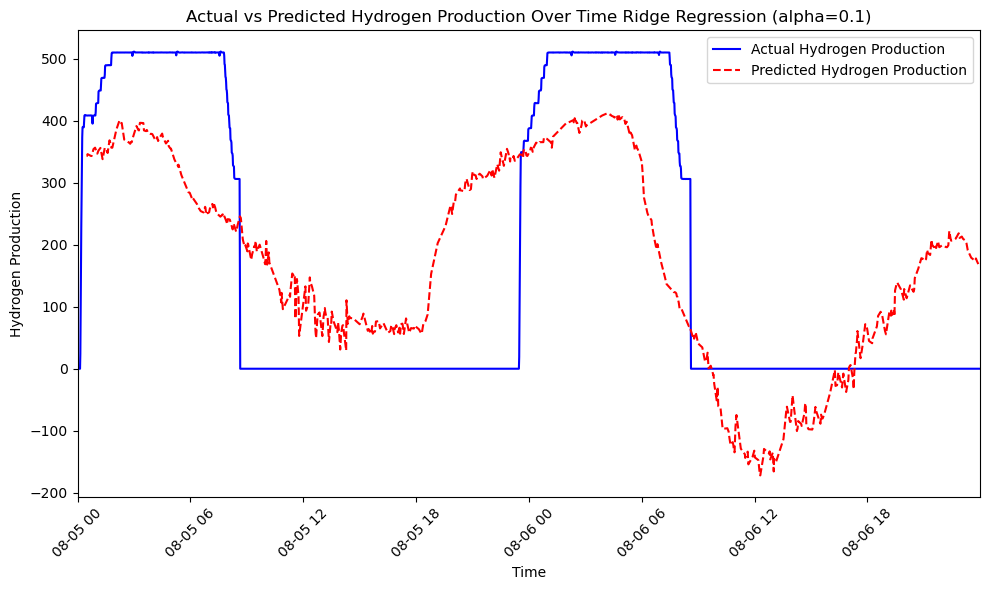


Evaluating model: Ridge Regression (alpha=1)
Model saved as models/regression/Ridge Regression (alpha=1)_model.pkl
Mean Absolute Error (MAE): 142.03
Mean Squared Error (MSE): 27581.77
R² Score: 0.49
Explained Variance Score: 0.49


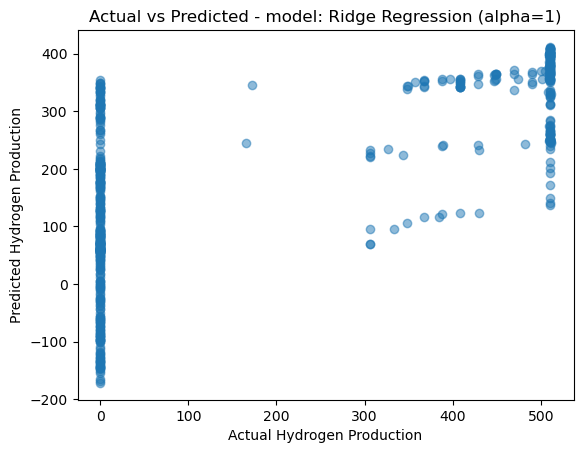

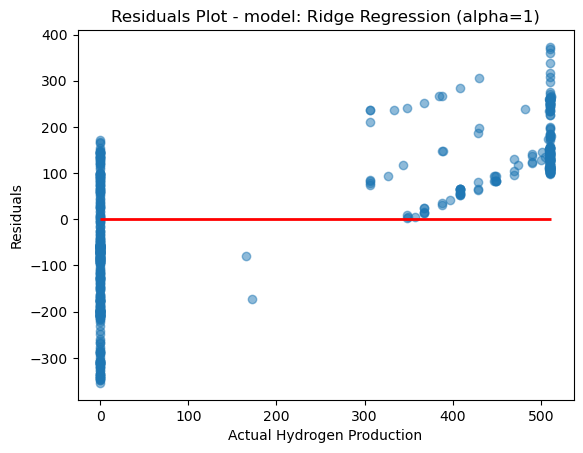

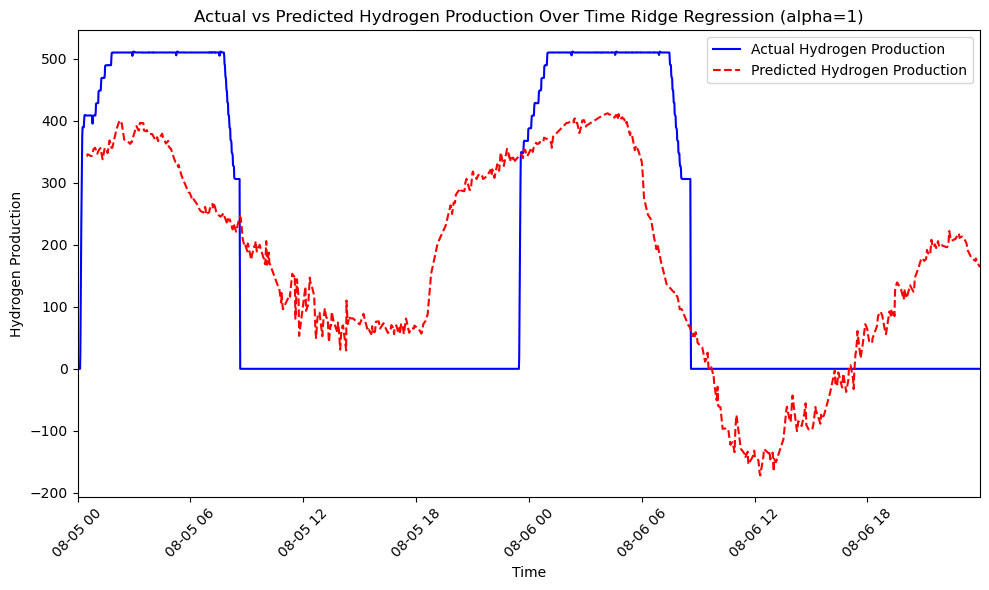

In [32]:
# testing some LR models
LRModel = LinearRegression()
Regression_Classifier(LRModel,X_train_scaled,y_train,X_test_scaled,y_test, "linear regression")

alpha_values = [0.1, 1]

# Lasso Regression (L1 regularization)
for alpha in alpha_values:
    lasso_model = Lasso(alpha=alpha)
    Regression_Classifier(lasso_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Lasso Regression (alpha={alpha})")

# Ridge Regression (L2 regularization)
for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    Regression_Classifier(ridge_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Ridge Regression (alpha={alpha})")



We have now seen that linear regression does not work well for this model. We have also seen that it does work well when ALL data is present (likely because the target variable is (roughly) in that dataset. We test for different models:

Evaluating model: XGBoost (learning_rate=0.01)
Model saved as models/regression/XGBoost (learning_rate=0.01)_model.pkl
Mean Absolute Error (MAE): 91.37
Mean Squared Error (MSE): 10116.44
R² Score: 0.81
Explained Variance Score: 0.81


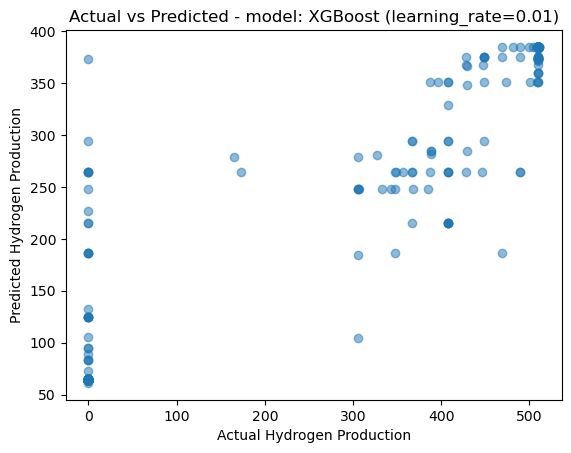

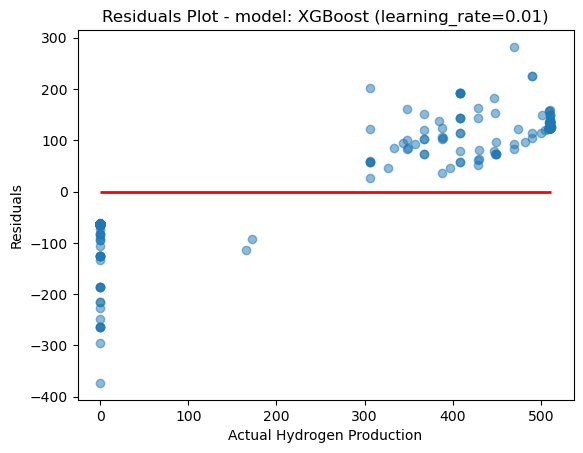

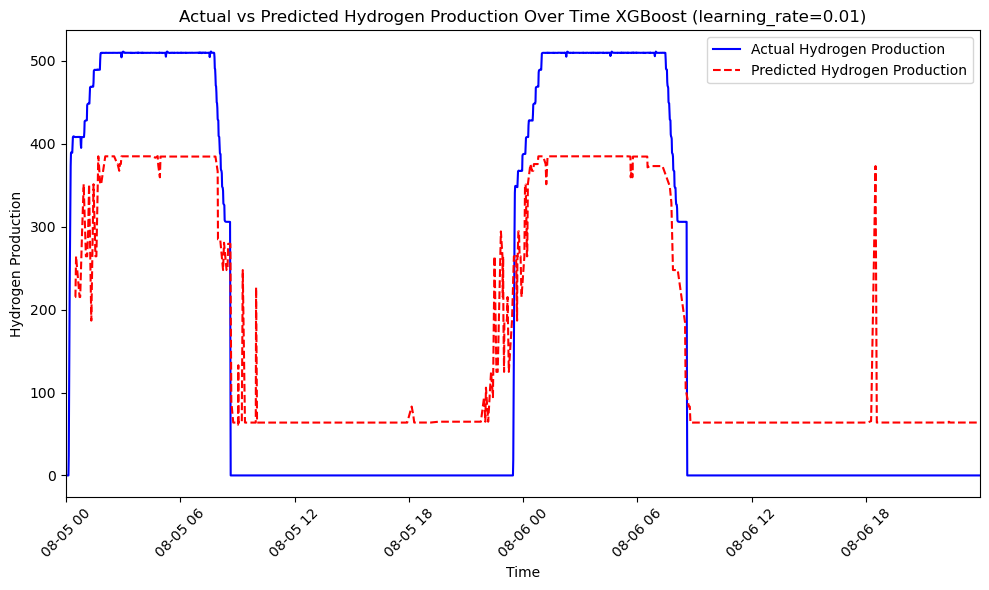


Evaluating model: XGBoost (learning_rate=0.1)
Model saved as models/regression/XGBoost (learning_rate=0.1)_model.pkl
Mean Absolute Error (MAE): 16.16
Mean Squared Error (MSE): 3050.07
R² Score: 0.94
Explained Variance Score: 0.94


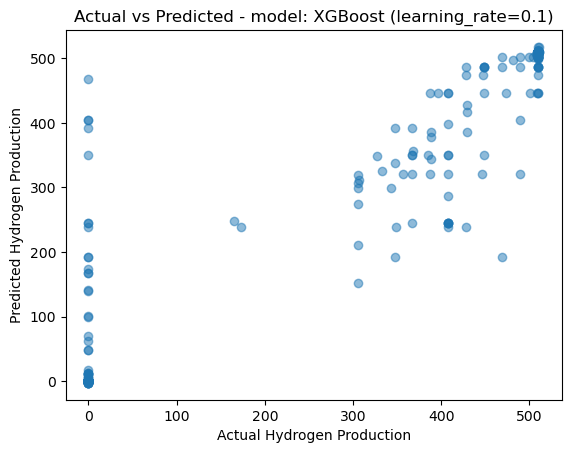

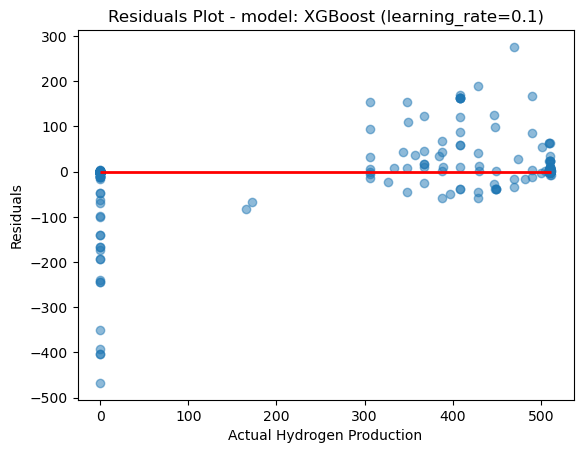

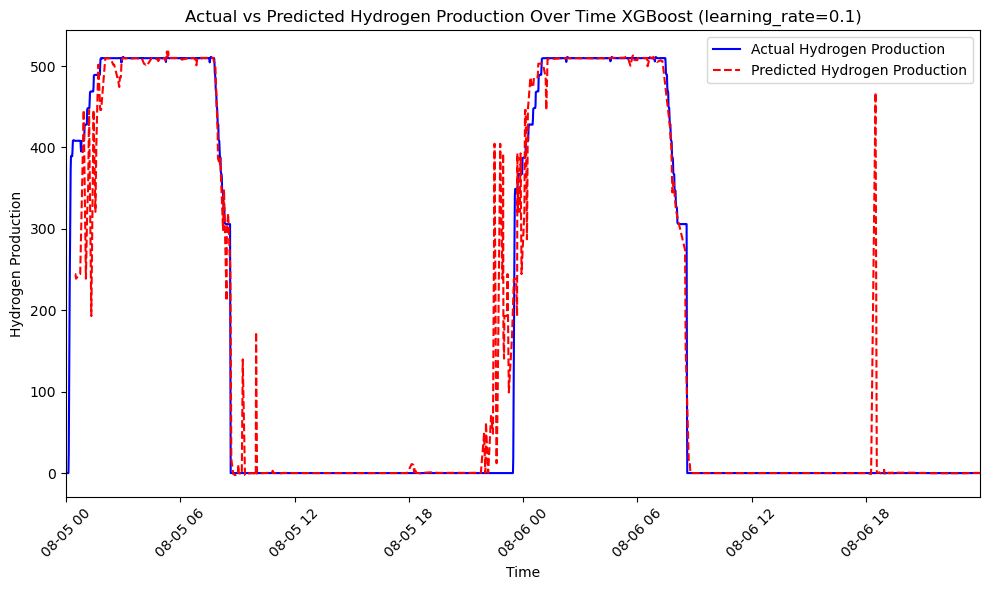


Evaluating model: XGBoost (learning_rate=0.2)
Model saved as models/regression/XGBoost (learning_rate=0.2)_model.pkl
Mean Absolute Error (MAE): 16.20
Mean Squared Error (MSE): 3107.72
R² Score: 0.94
Explained Variance Score: 0.94


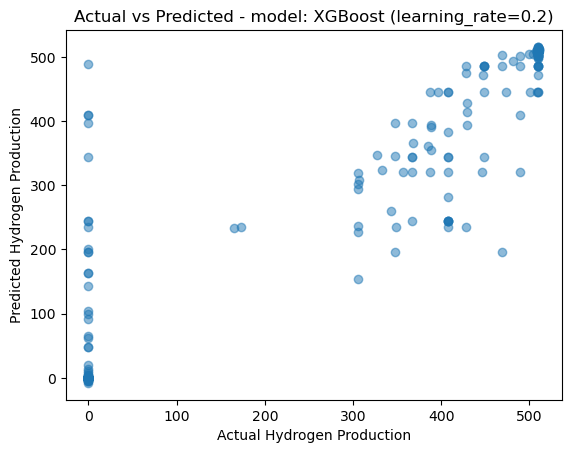

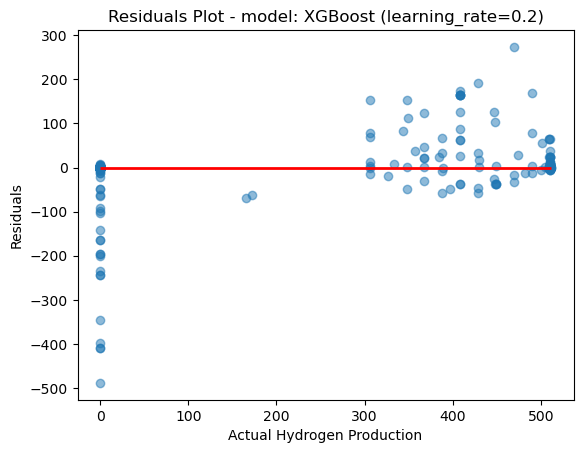

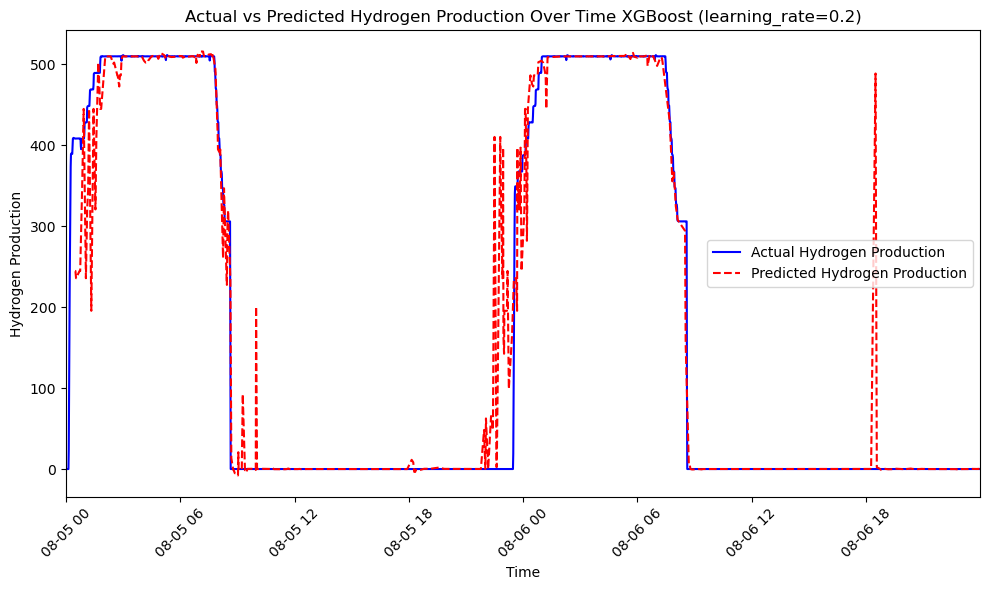


Evaluating model: Random Forest (n_estimators=50)
Model saved as models/regression/Random Forest (n_estimators=50)_model.pkl
Mean Absolute Error (MAE): 14.11
Mean Squared Error (MSE): 2463.36
R² Score: 0.95
Explained Variance Score: 0.95


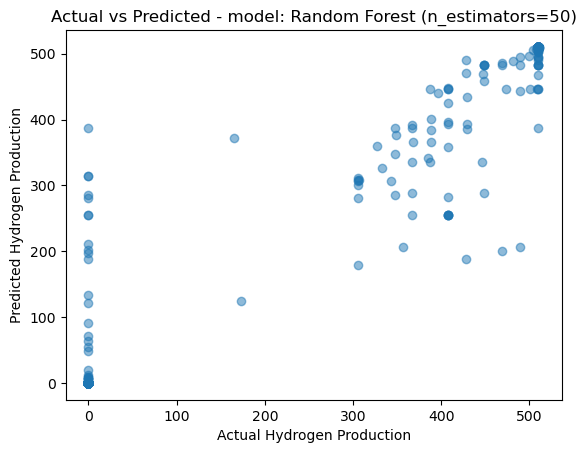

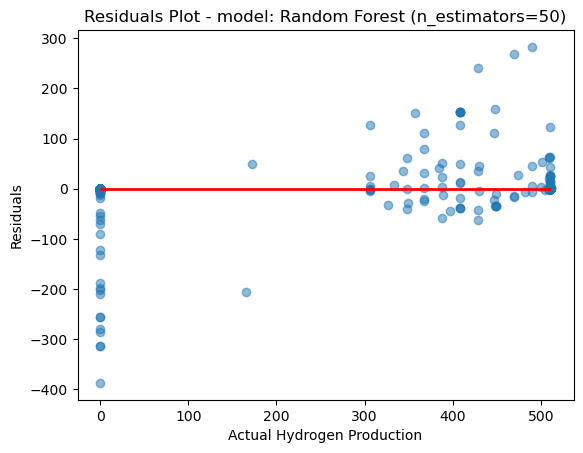

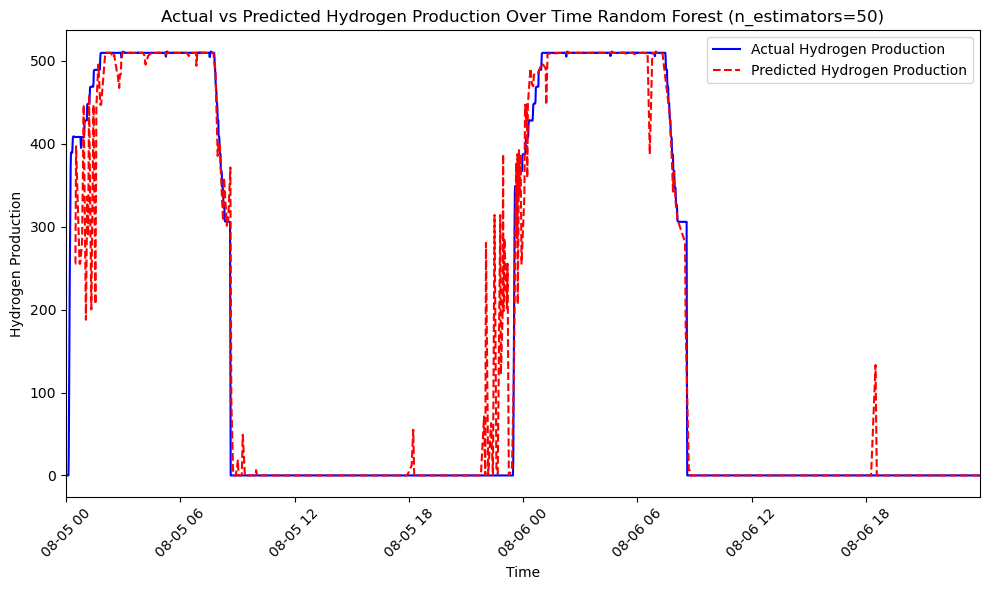


Evaluating model: Random Forest (n_estimators=100)
Model saved as models/regression/Random Forest (n_estimators=100)_model.pkl
Mean Absolute Error (MAE): 14.18
Mean Squared Error (MSE): 2513.76
R² Score: 0.95
Explained Variance Score: 0.95


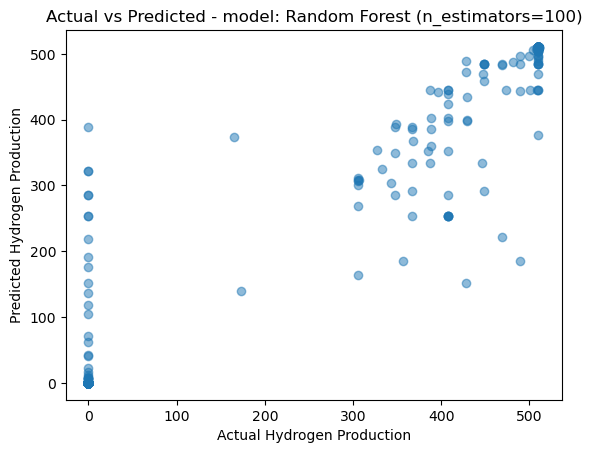

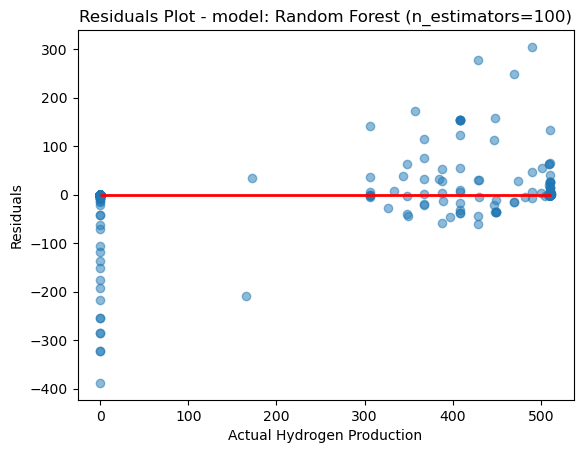

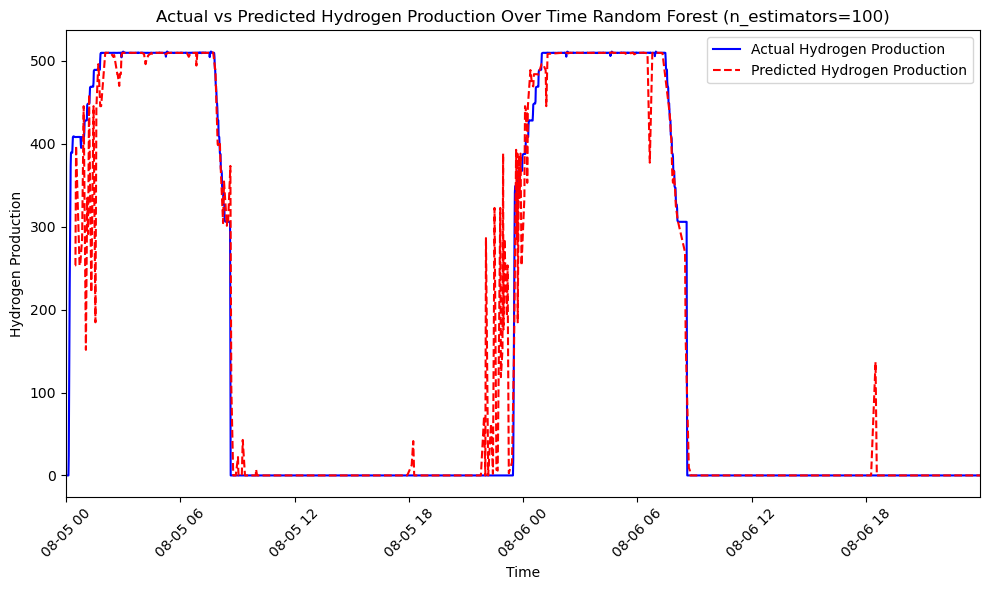


Evaluating model: Random Forest (n_estimators=200)
Model saved as models/regression/Random Forest (n_estimators=200)_model.pkl
Mean Absolute Error (MAE): 14.13
Mean Squared Error (MSE): 2532.53
R² Score: 0.95
Explained Variance Score: 0.95


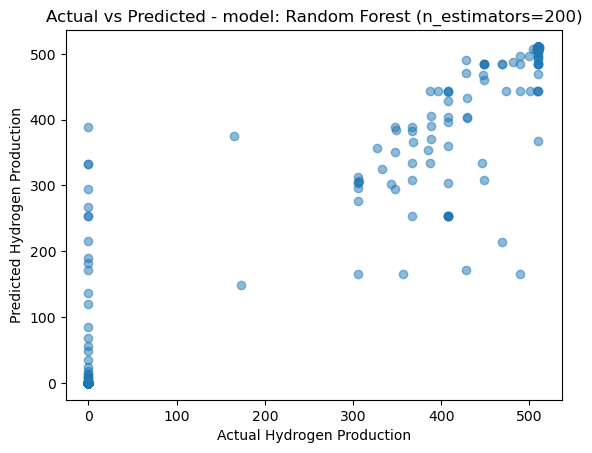

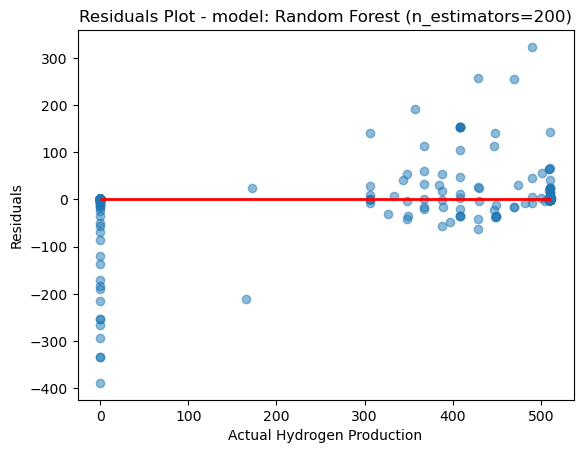

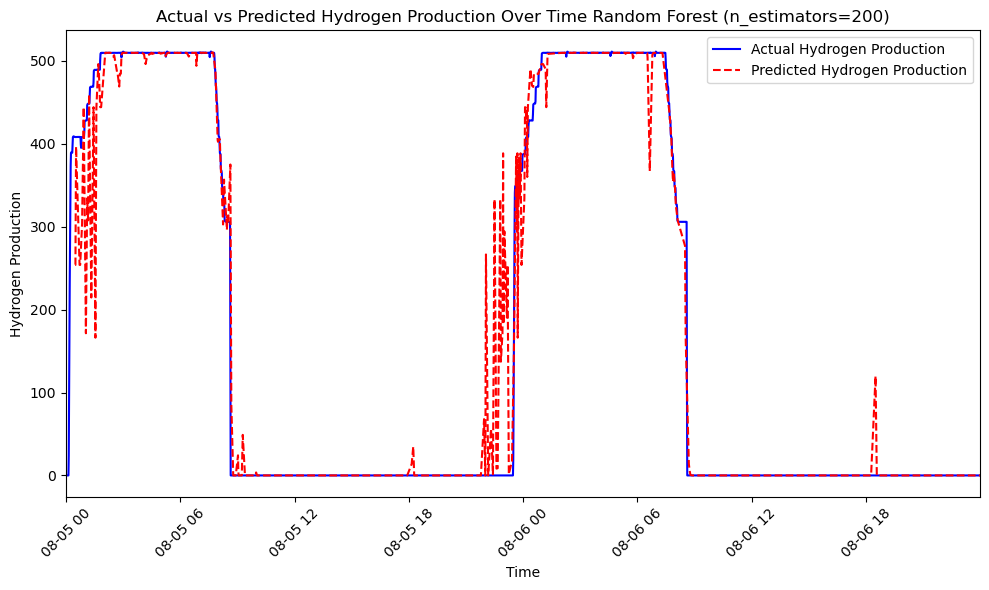


Evaluating model: KNN (n_neighbors=3)
Model saved as models/regression/KNN (n_neighbors=3)_model.pkl
Mean Absolute Error (MAE): 13.92
Mean Squared Error (MSE): 2806.27
R² Score: 0.95
Explained Variance Score: 0.95


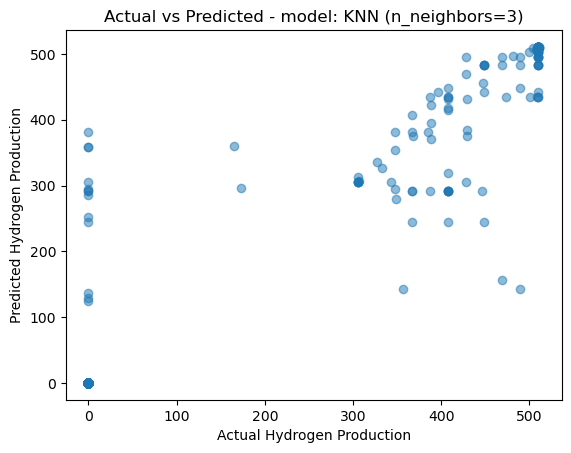

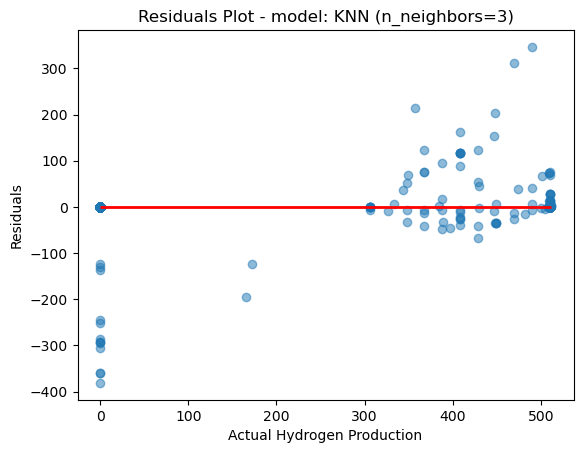

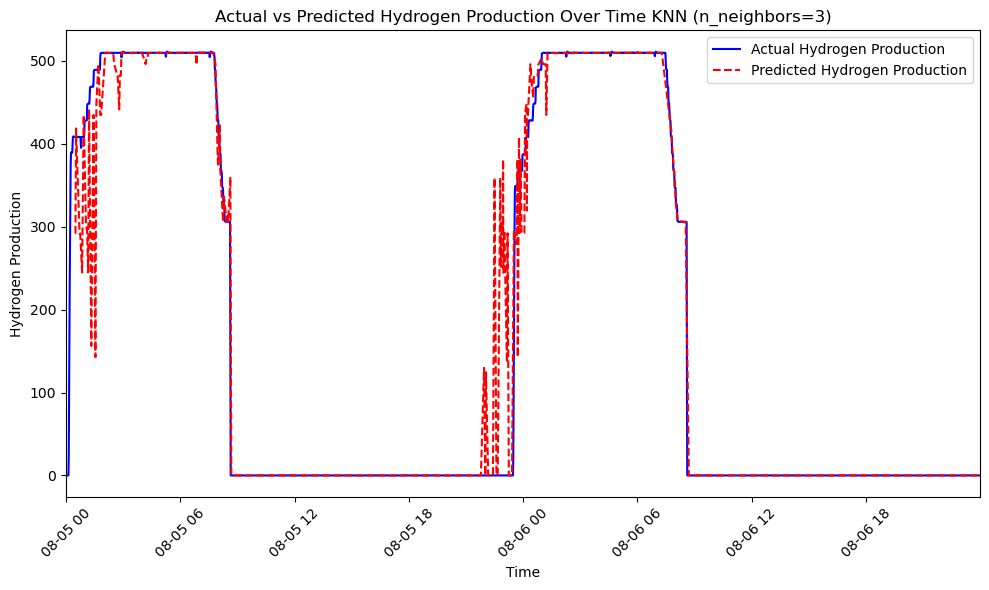


Evaluating model: KNN (n_neighbors=5)
Model saved as models/regression/KNN (n_neighbors=5)_model.pkl
Mean Absolute Error (MAE): 15.13
Mean Squared Error (MSE): 2919.61
R² Score: 0.95
Explained Variance Score: 0.95


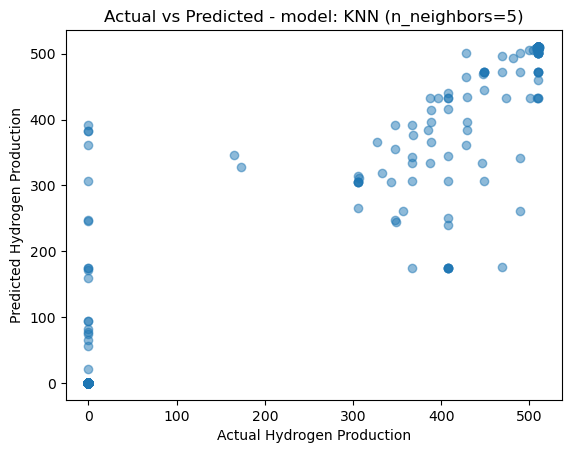

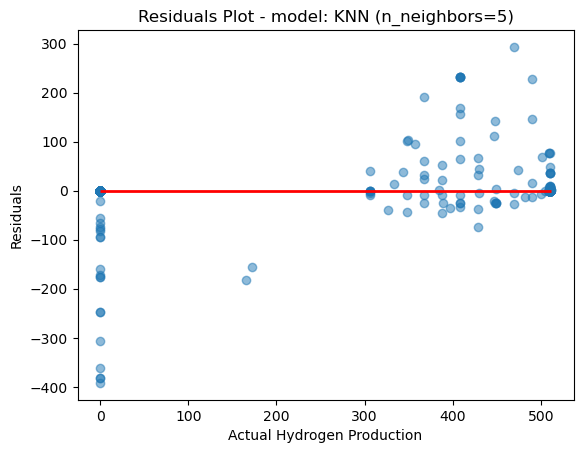

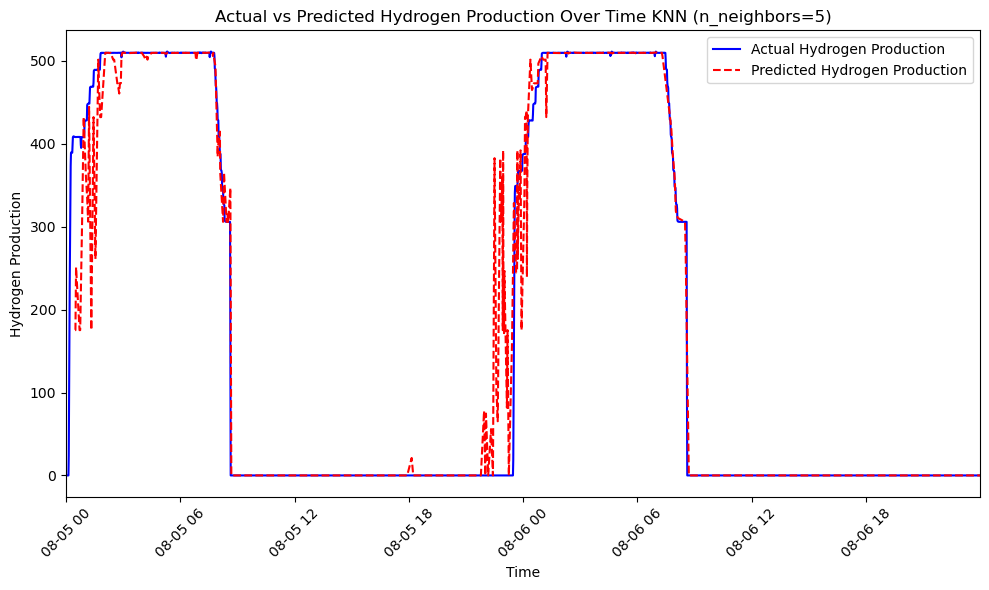


Evaluating model: KNN (n_neighbors=7)
Model saved as models/regression/KNN (n_neighbors=7)_model.pkl
Mean Absolute Error (MAE): 14.78
Mean Squared Error (MSE): 2652.94
R² Score: 0.95
Explained Variance Score: 0.95


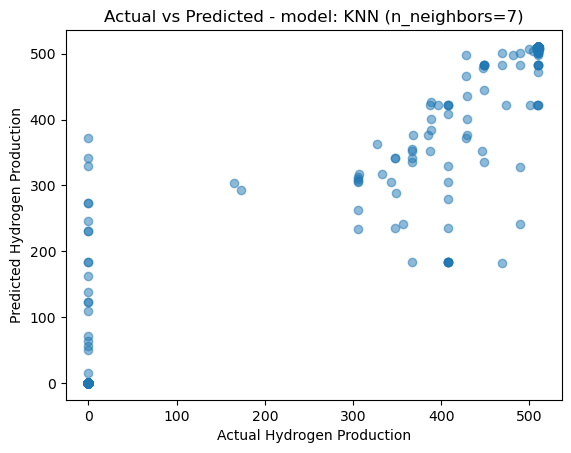

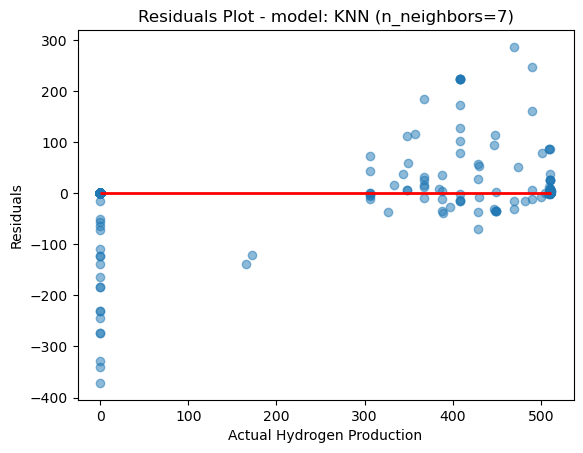

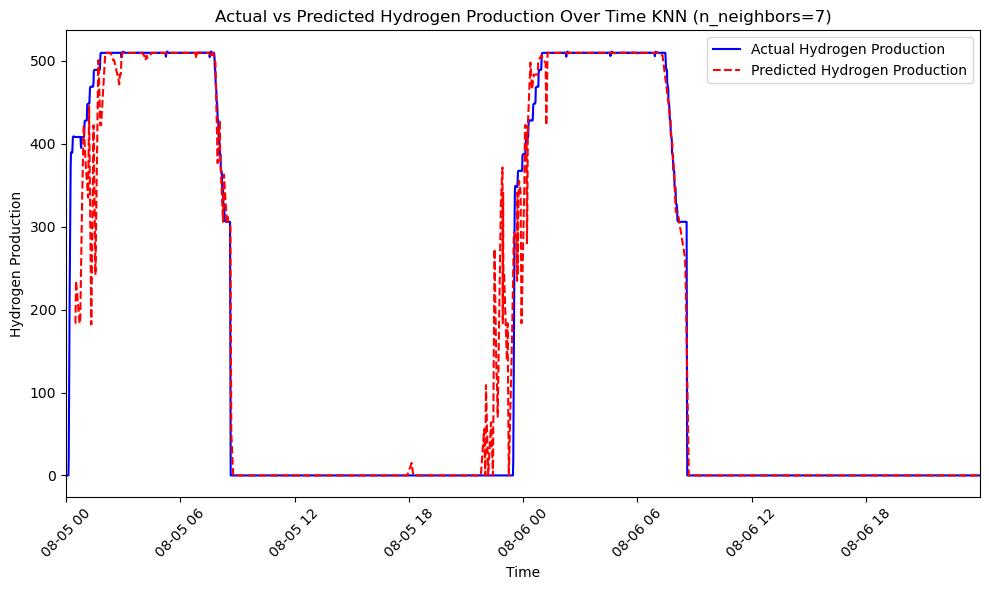


Evaluating model: KNN (n_neighbors=9)
Model saved as models/regression/KNN (n_neighbors=9)_model.pkl
Mean Absolute Error (MAE): 14.93
Mean Squared Error (MSE): 2504.94
R² Score: 0.95
Explained Variance Score: 0.95


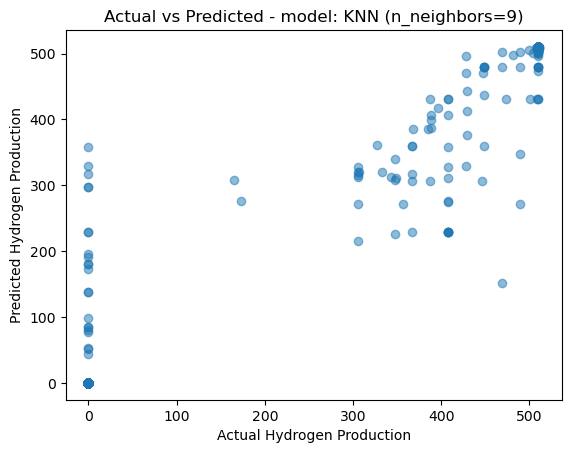

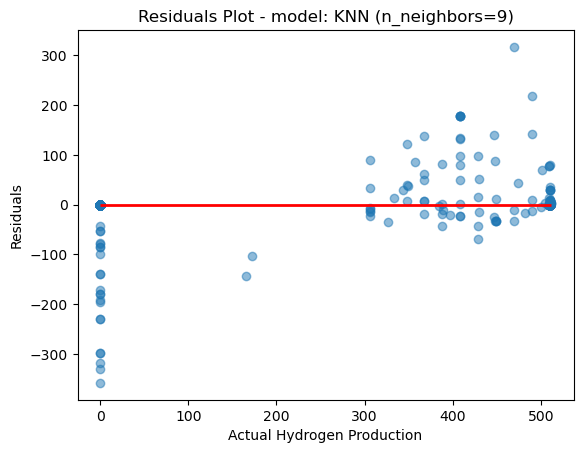

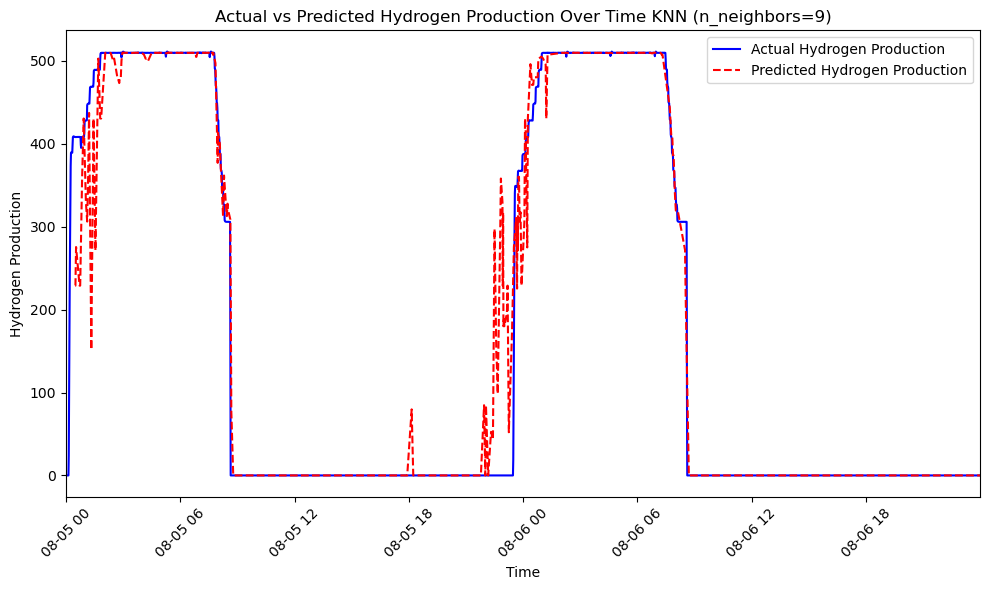


Evaluating model: SVM (kernel=linear)
Model saved as models/regression/SVM (kernel=linear)_model.pkl
Mean Absolute Error (MAE): 138.37
Mean Squared Error (MSE): 31085.98
R² Score: 0.43
Explained Variance Score: 0.45


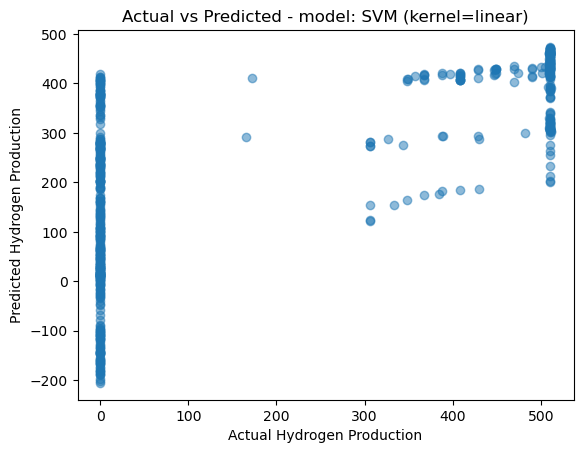

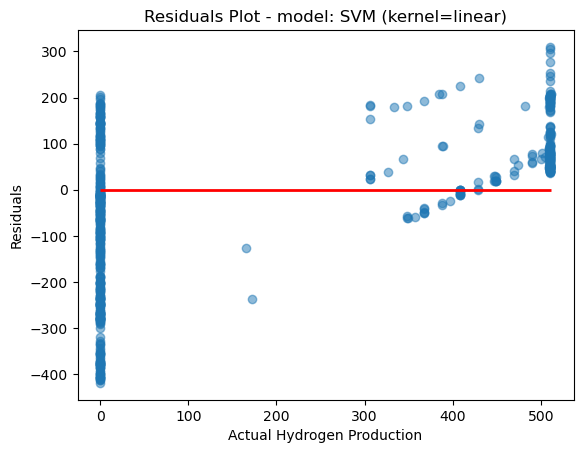

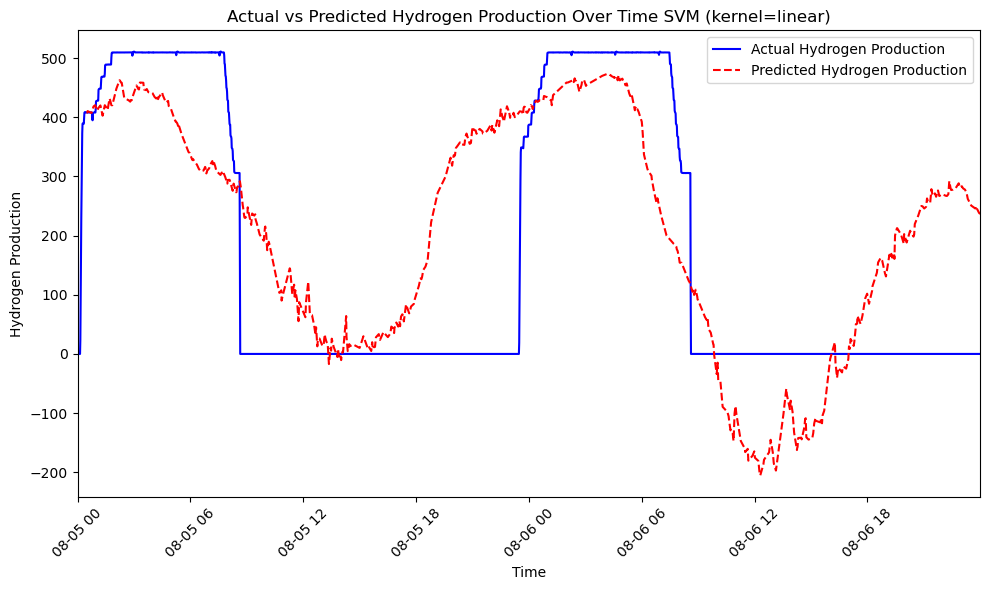


Evaluating model: SVM (kernel=poly)
Model saved as models/regression/SVM (kernel=poly)_model.pkl
Mean Absolute Error (MAE): 178.27
Mean Squared Error (MSE): 84161.68
R² Score: -0.55
Explained Variance Score: 0.02


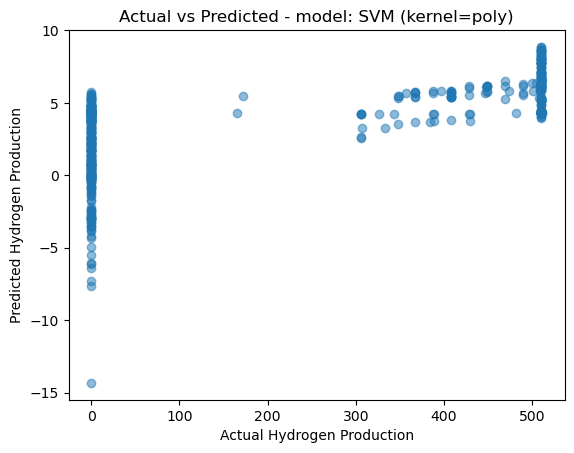

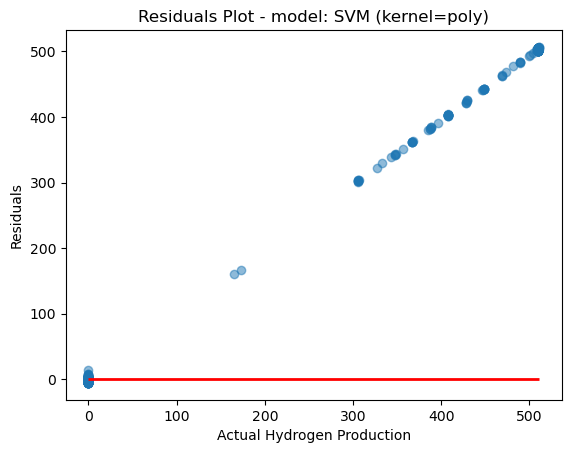

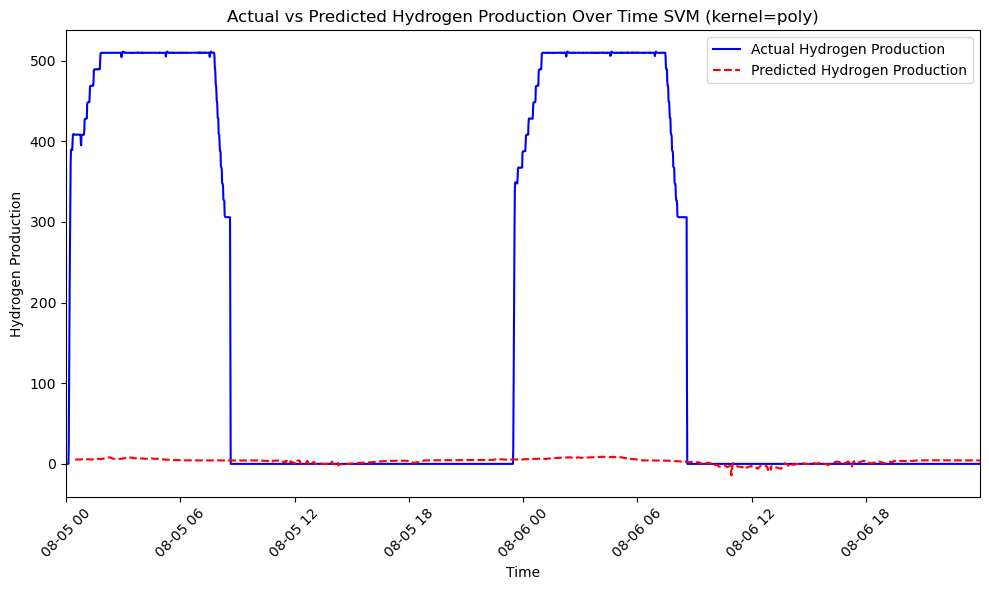


Evaluating model: SVM (kernel=rbf)
Model saved as models/regression/SVM (kernel=rbf)_model.pkl
Mean Absolute Error (MAE): 102.72
Mean Squared Error (MSE): 24073.33
R² Score: 0.56
Explained Variance Score: 0.56


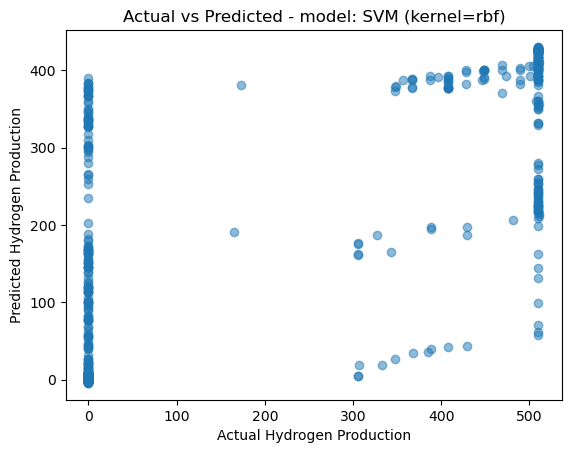

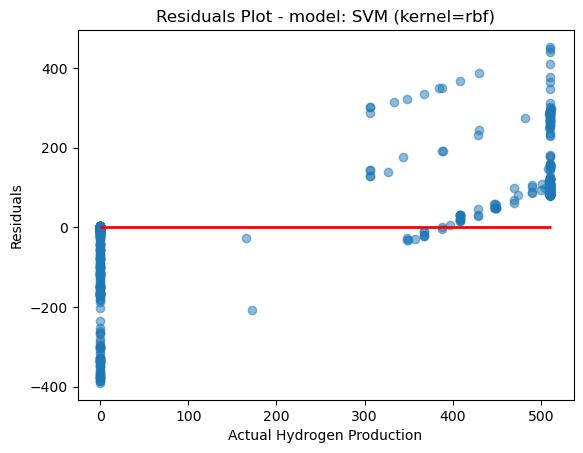

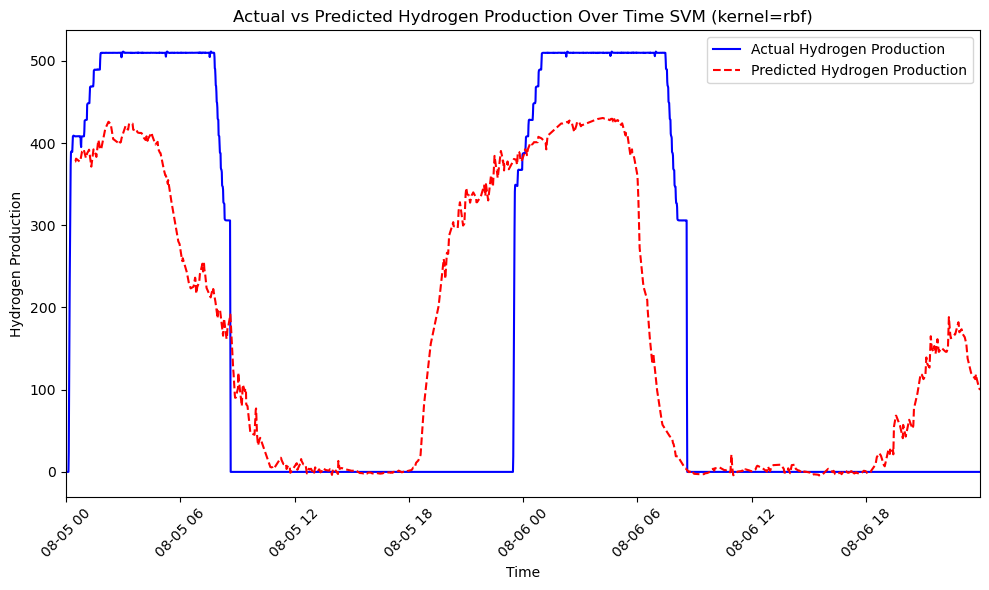


Evaluating model: Decision Tree (max_depth=5)
Model saved as models/regression/Decision Tree (max_depth=5)_model.pkl
Mean Absolute Error (MAE): 17.78
Mean Squared Error (MSE): 3070.17
R² Score: 0.94
Explained Variance Score: 0.94


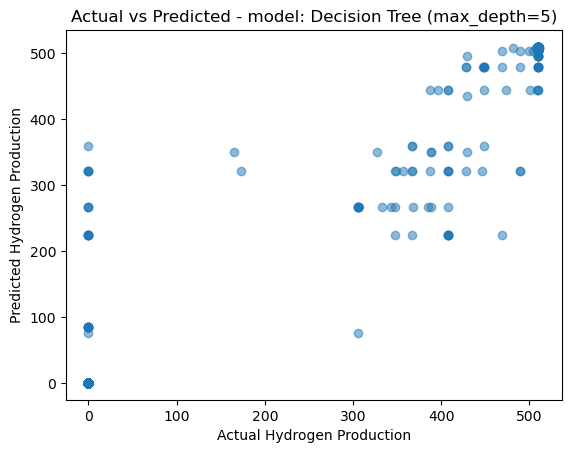

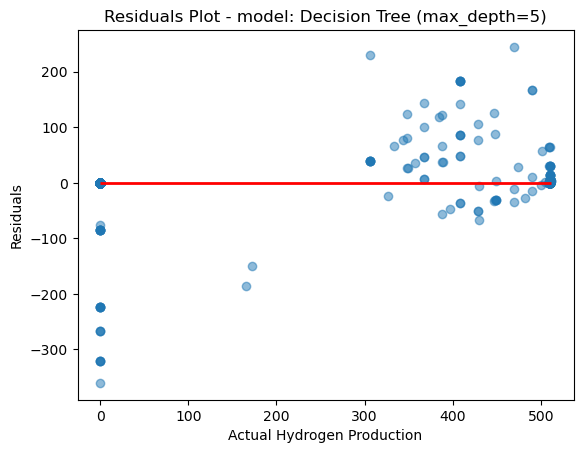

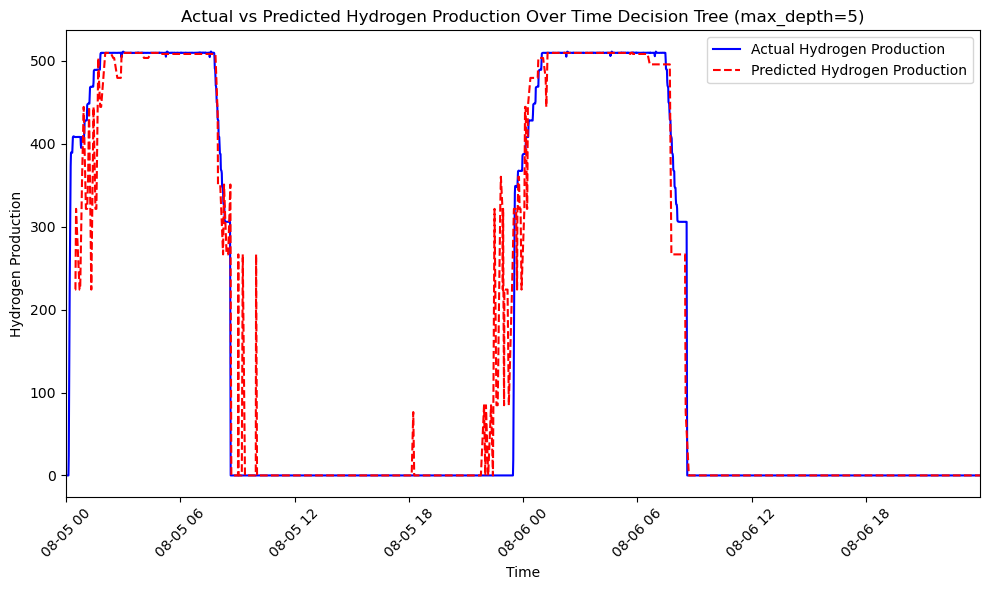


Evaluating model: Decision Tree (max_depth=10)
Model saved as models/regression/Decision Tree (max_depth=10)_model.pkl
Mean Absolute Error (MAE): 12.44
Mean Squared Error (MSE): 2262.94
R² Score: 0.96
Explained Variance Score: 0.96


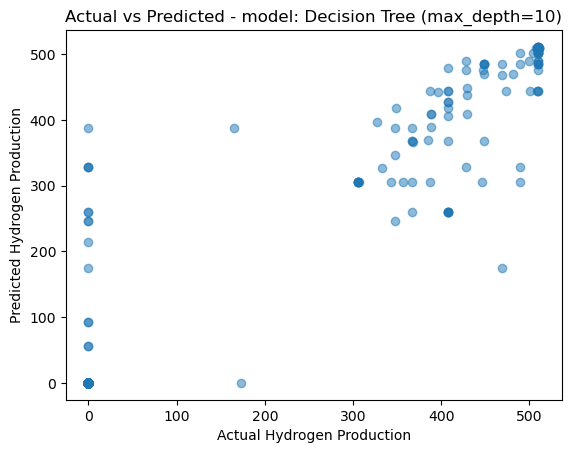

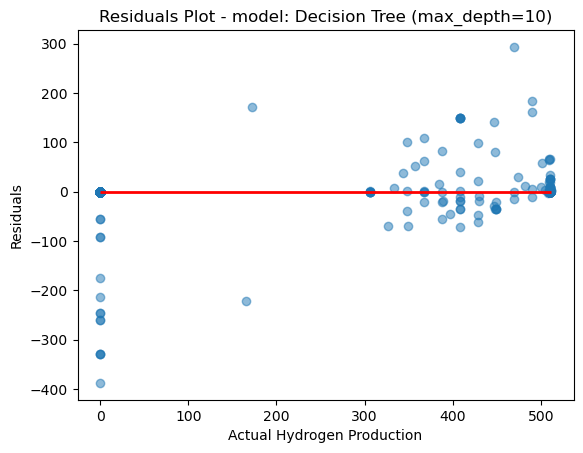

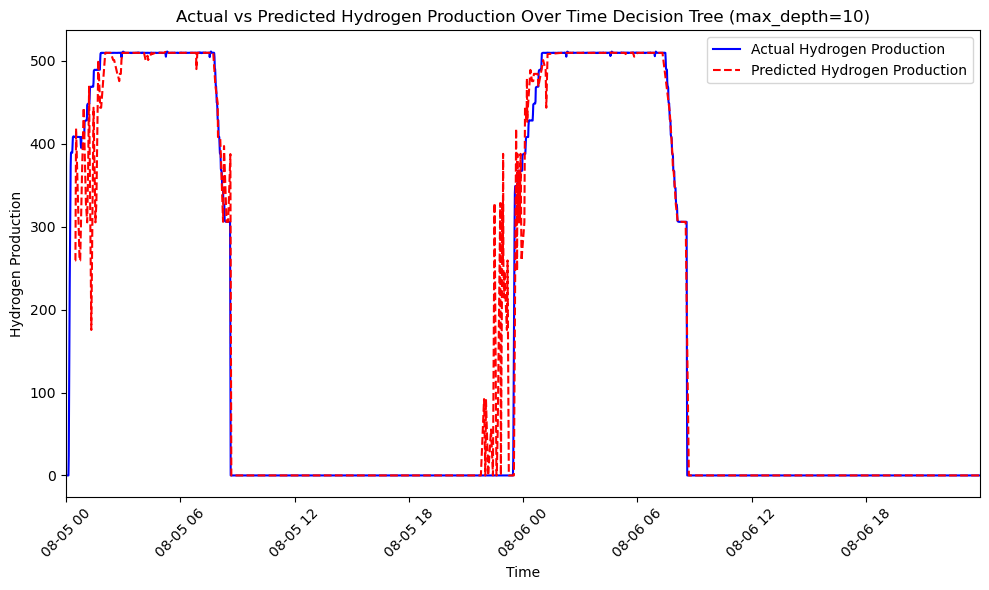


Evaluating model: Decision Tree (max_depth=20)
Model saved as models/regression/Decision Tree (max_depth=20)_model.pkl
Mean Absolute Error (MAE): 12.82
Mean Squared Error (MSE): 2743.02
R² Score: 0.95
Explained Variance Score: 0.95


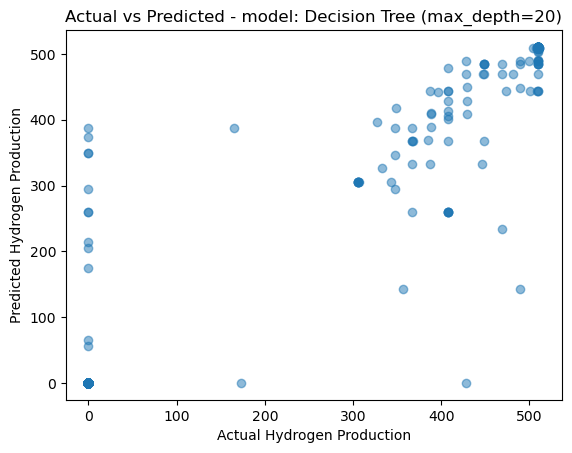

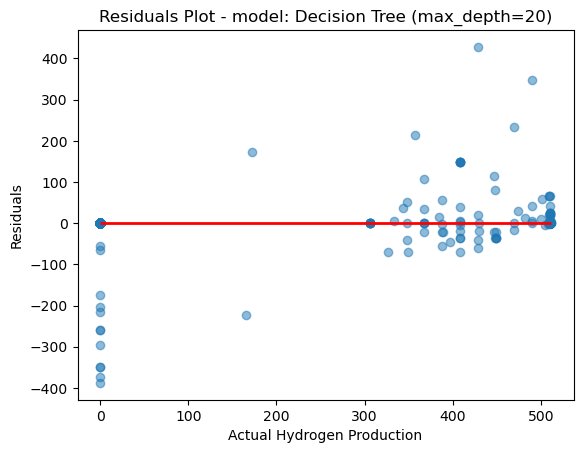

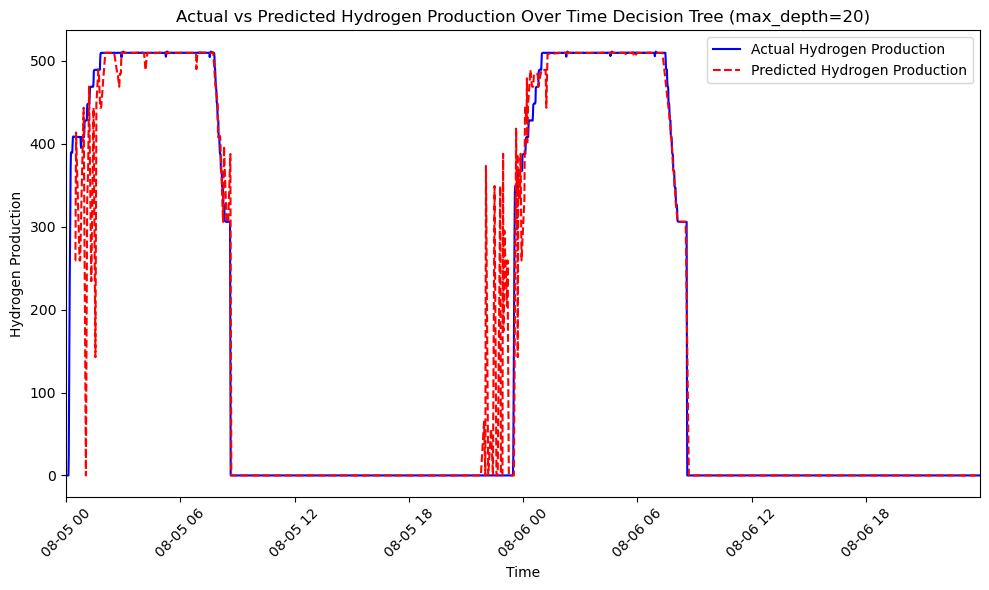

In [38]:
# XGBoost Regressor with different learning rates and max_depth
learning_rates = [0.01, 0.1, 0.2]
for rate in learning_rates:
    xgb_model = XGBRegressor(learning_rate=rate, n_estimators=100, max_depth=5, random_state=42)
    Regression_Classifier(xgb_model, X_train_scaled, y_train, X_test_scaled, y_test, f"XGBoost (learning_rate={rate})")

# Random Forest Regressor with different numbers of trees
for n_estimators in [50, 100, 200]:
    rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    Regression_Classifier(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Random Forest (n_estimators={n_estimators})")

# KNN: Regressor
for n in [3, 5, 7, 9]:
    knn_model = KNeighborsRegressor(n_neighbors=n)
    Regression_Classifier(knn_model, X_train_scaled, y_train, X_test_scaled, y_test, f"KNN (n_neighbors={n})")

# SVM Regressor with different kernels
kernels = ['linear', 'poly', 'rbf'] # Watch out, linear takes a while to run for some reason
for kernel in kernels:
    svr_model = SVR(kernel=kernel, C=1.0, epsilon=0.1)
    Regression_Classifier(svr_model, X_train_scaled, y_train, X_test_scaled, y_test, f"SVM (kernel={kernel})")

# Decision Tree Regressor with different max_depth values (10 was best so we add higher values now)
for depth in [5, 10, 20]:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    Regression_Classifier(dt_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Decision Tree (max_depth={depth})")

### Further model evaluation

Both the actual production and predicted production are integrated over time to determine accuracy.

In [40]:
def integrate_h2(*var, name):
    plt.figure()
    if isinstance(var[0], str):
        data = globals()[var[0]]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
        plt.title('Actual hydrogen production over time')
    else:
        time = time_test_sorted
        values = y_pred_sorted
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
        plt.title('Predicted hydrogen production over time')

    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join("figures/regression", f"H2 integrated - {name}.png"), dpi=300, bbox_inches='tight')

    plt.show()
    return H2Prod

Evaluating model: Decision Tree (max_depth=10)
Model saved as models/regression/Decision Tree (max_depth=10)_model.pkl
Mean Absolute Error (MAE): 12.44
Mean Squared Error (MSE): 2262.94
R² Score: 0.96
Explained Variance Score: 0.96


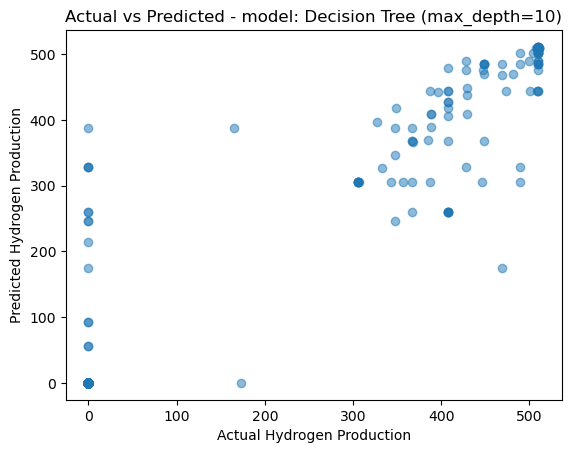

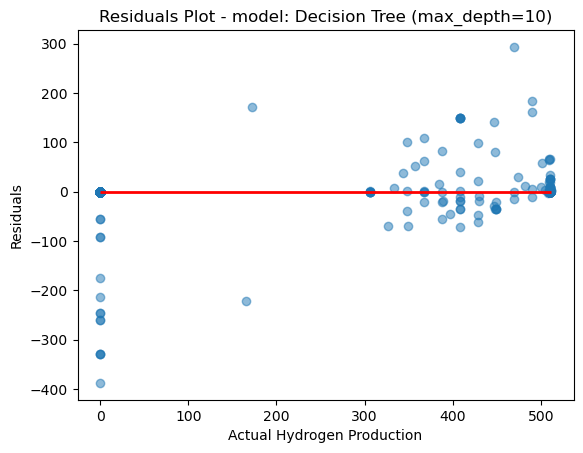

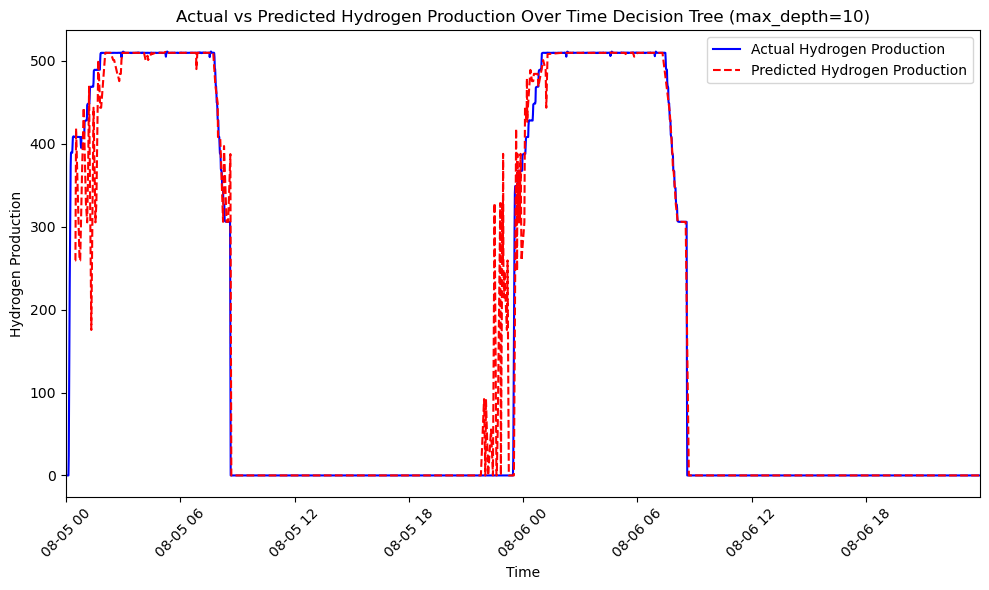

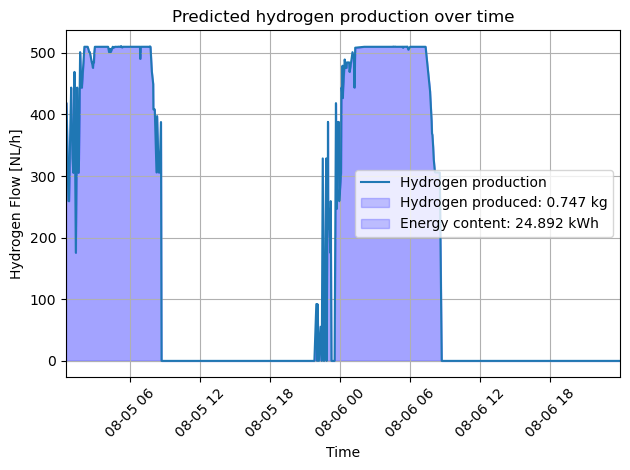

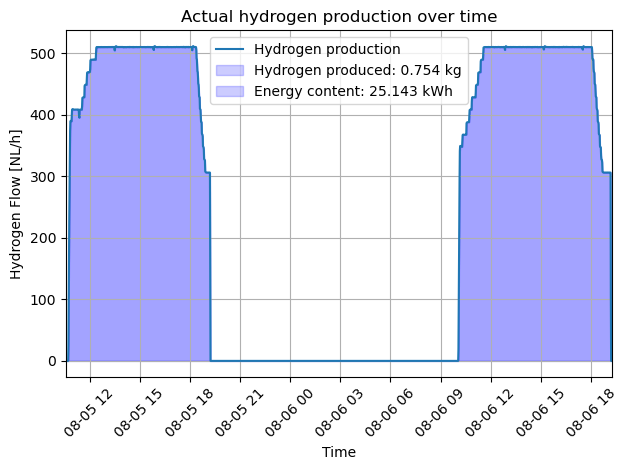

Underestimation: 0.008 kg H2
Percentage error: -0.996%


In [42]:
# Lets evaluate the best performing model and integrate over time to determine difference:
# Best model so far:  DT regressor with depth = 10
globals()['Electrolyser_Hydrogen_Flow'] = pd.read_pickle(os.path.join(subfolder, "Electrolyser_Hydrogen_Flow_Rate.pkl"))


dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
time_test_sorted, y_pred_sorted = Regression_Classifier(dt_model, X_train_scaled, y_train, X_test_scaled, y_test, f"Decision Tree (max_depth={10})")

H2Prod_pred = integrate_h2(time_test_sorted, y_pred_sorted, name = "predicted")

H2Prod_act = integrate_h2('Electrolyser_Hydrogen_Flow', name = "actual")
estimation_diff = H2Prod_pred - H2Prod_act

# Calculate the percentage error
if H2Prod_act != 0:
    percentage_error = (estimation_diff / H2Prod_act) * 100
else:
    percentage_error = 0  # If actual production is 0, avoid division by 0

# Print the results
if estimation_diff > 0:
    print(f"Overestimation: {estimation_diff:.3f} kg H2")
elif estimation_diff < 0:
    print(f"Underestimation: {abs(estimation_diff):.3f} kg H2")
else:
    print("No estimation error.")

print(f"Percentage error: {percentage_error:.3f}%")


# Overfitting testing
The models above gave very good results, now we should check the model's performance on new, never before seen data. Therefore another day is imported.

In [34]:
# Importing pickle files:
subfolder = "dataframes-1-min-2" # data of another day to validate the model on

pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')]

# Load all pickle files available, or just the ones we need
DataframesToLoad = ["PV_Inverter_Active_Power","Temperature_Monitoring_Outdoor_Temperarture", "Electrolyser_Hydrogen_Flow_Rate"]

alldataframes = []
column_names = []

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl")) # import the relevant dataframes
    print(f"Loaded {var_name} from {subfolder}")
    df = globals()[var_name]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var_name}')


# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df.head()

# Creatint a target column (1 for hydrogen production, 0 otherwise)
combined_df = pd.concat([combined_df, 
                         (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int).rename('H2_Produced')], 
                         axis=1)


FileNotFoundError: [Errno 2] No such file or directory: 'dataframes-1-min-2'

In [36]:
# Loading the model:
models = [f for f in os.listdir('models/classification') if f.endswith('.pkl')] # loads all models in the folder


for model in models: # Tries classification for all models in the folders
    with open(f'models/classification/{model}', 'rb') as model_file:
        loaded_model = pickle.load(model_file)
    
    trained_features = loaded_model.feature_names_in_  # I needed to know the feature name order, because it would only take it in the same order
    new_data = combined_df.drop(columns=['Electrolyser_Hydrogen_Flow_Rate'])
    print("Features used during training:", trained_features)
    print("Features in new_data:", new_data.columns)
    
    new_data = combined_df.drop(columns = ['Electrolyser_Hydrogen_Flow_Rate','H2_Produced'])
    y_true = combined_df['H2_Produced']  # True labels
    new_data = new_data[trained_features]
    
    # Make predictions with the loaded model
    predictions = loaded_model.predict(new_data)  # Replace 'new_data' with your new input data
    confusionmatrix = confusion_matrix(y_true, predictions)
    
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusionmatrix, display_labels=loaded_model.classes_)  # Replace with actual class names if needed
    disp.plot()
    plt.title(f"Confusion Matrix - Model: {loaded_model}")
    plt.show()


Features used during training: ['Temperature_Monitoring_Outdoor_Temperarture' 'PV_Inverter_Active_Power']
Features in new_data: Index(['Temperature_Monitoring_Outdoor_Temperarture',
       'PV_Inverter_Active_Power', 'time', 'H2_Produced'],
      dtype='object')


ValueError: Classification metrics can't handle a mix of continuous and binary targets

Loaded PV_Inverter_Active_Power from dataframes-1-min-2
Loaded Temperature_Monitoring_Outdoor_Temperarture from dataframes-1-min-2
Loaded Electrolyser_Hydrogen_Flow_Rate from dataframes-1-min-2
Mean Absolute Error (MAE): 169.37
Mean Squared Error (MSE): 83194.97
R² Score: -0.53
Explained Variance Score: 0.00


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


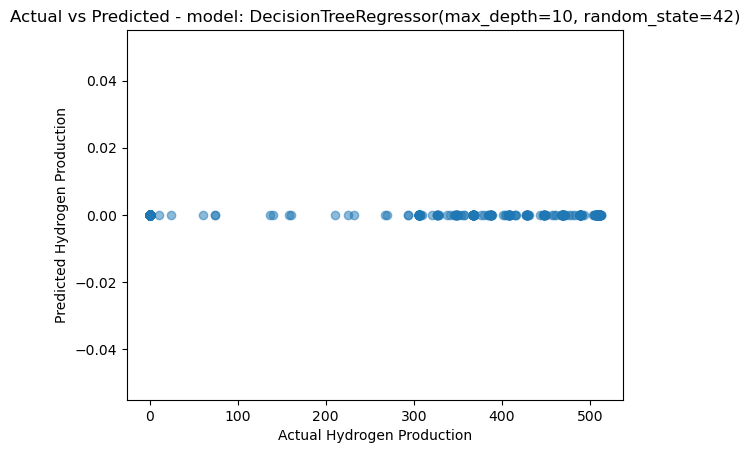

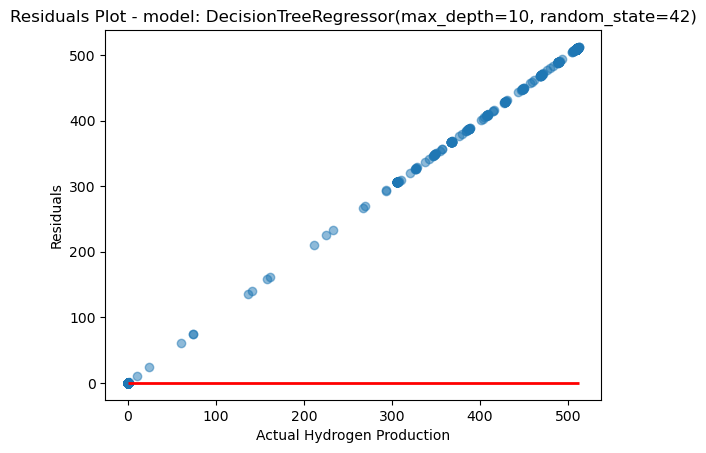

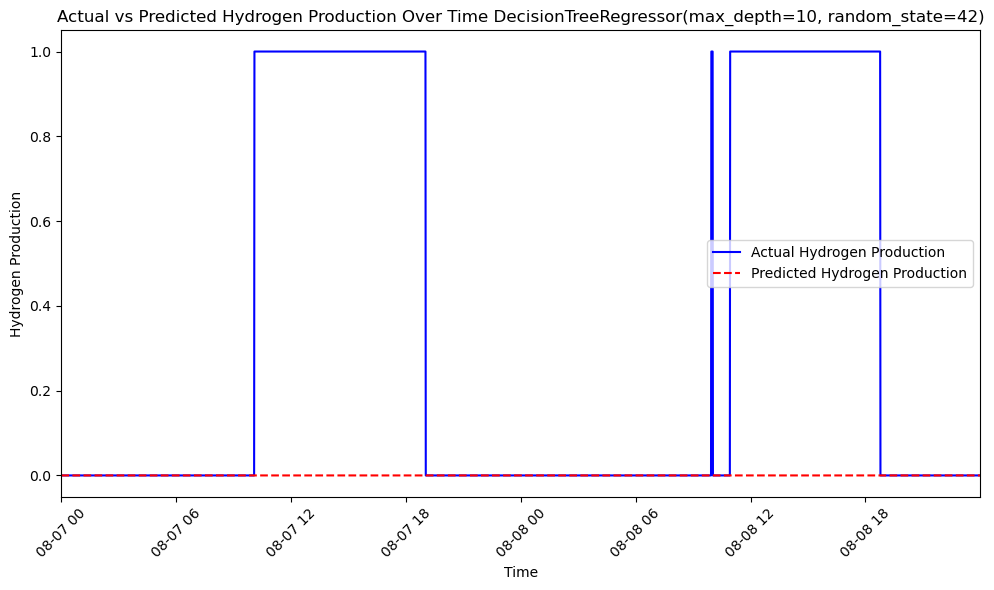

In [92]:
# Loading the model for regression:
# Importing pickle files:
subfolder = "dataframes-1-min-2" # Try data of another day to validate the model
figsubfolder = "figures/validation" 
pickle_files = [os.path.splitext(f)[0] for f in os.listdir(subfolder) if f.endswith('.pkl')] # get all dataframes

# Load all pickle files available, or just the ones we need
DataframesToLoad = ["PV_Inverter_Active_Power","Temperature_Monitoring_Outdoor_Temperarture", "Electrolyser_Hydrogen_Flow_Rate"]

alldataframes = []
column_names = []

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl")) # Load relevant dataframes
    print(f"Loaded {var_name} from {subfolder}")
    df = globals()[var_name]
    alldataframes.append(df[['value_float']])
    column_names.append(f'{var_name}')


# Combine all DataFrames into one
combined_df = pd.concat(alldataframes, axis=1)
combined_df.columns = column_names
combined_df['time'] = globals()[DataframesToLoad[0]]['time']

combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()] # Remove duplicates (gave problems without)
combined_df.fillna(0, inplace=True) # Remove NaN and insert 0 (gave problems without)
combined_df.head()

# Create the binary target column (1 for hydrogen production, 0 otherwise)
combined_df = pd.concat([combined_df, 
                         (combined_df['Electrolyser_Hydrogen_Flow_Rate'] > 10).astype(int).rename('H2_Produced')], 
                         axis=1)

with open('models/regression/Decision Tree (max_depth=10)_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)
    name = loaded_model

y_true = combined_df['Electrolyser_Hydrogen_Flow_Rate']   # True labels
time_test = combined_df.loc[combined_df.index, 'time']    # Get corresponding time for the prediction data
new_data = combined_df.drop(columns = ['Electrolyser_Hydrogen_Flow_Rate','H2_Produced','time'])


# Make predictions with the loaded model
y_pred = loaded_model.predict(new_data)  # Replace 'new_data' with your new input data
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
# Performance testing:

# We need to sort the predictions to make a plot:
predicted_df = pd.DataFrame({'time': time_test, 'predicted': y_pred})
predicted_df = predicted_df.sort_values(by='time')
time_test_sorted = predicted_df['time']
y_pred_sorted = predicted_df['predicted']

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")
evs = explained_variance_score(y_true, y_pred)
print(f"Explained Variance Score: {evs:.2f}")

plt.figure()
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Hydrogen Production")
plt.ylabel("Predicted Hydrogen Production")
plt.title(f"Actual vs Predicted - model: {name}")
plt.savefig(os.path.join(figsubfolder, f"predictions - {name}.png"), dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
residuals = y_true - y_pred
plt.scatter(y_true, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_true.min(), xmax=y_true.max(), colors='red', linewidth=2)
plt.xlabel("Actual Hydrogen Production")
plt.ylabel("Residuals")
plt.title(f"Residuals Plot - model: {name}")
plt.savefig(os.path.join(figsubfolder, f"Residuals Plot - {name}.png"), dpi=300, bbox_inches='tight')
plt.show()
    
plt.figure(figsize=(10, 6))
test_index = X_test.index
# Plot actual vs time
plt.plot(combined_df['time'], combined_df['H2_Produced'], label='Actual Hydrogen Production', color='blue')
    
# Plot predicted vs time
plt.plot(time_test_sorted, y_pred_sorted, label='Predicted Hydrogen Production', color='red', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Hydrogen Production')
plt.title(f'Actual vs Predicted Hydrogen Production Over Time {name}')
plt.xlim(min(combined_df['time']), max(combined_df['time']))
plt.legend()

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figsubfolder, f"timeseries Actual vs predicted - {name}.png"), dpi=300, bbox_inches='tight')
plt.show()
print()
print()



### Concluding
We conclude that the prediction slightly underestimates the hydrogen production. Though, the promising results do not yet include variability in weather data and may even be overfitted. This should be examined further at a later instance.

In [130]:
# Setting up plotting layout
figdim=(6.4, 4.8)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod